In [33]:

import os
import torch
import torch.nn as nn
import torch.optim as optim

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from collections import Counter

from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

# Dataset Exploration (BreakHis Structure)

In [34]:
base_path = "/kaggle/input/datasets/waseemalastal/breakhis-breast-cancer-histopathological-dataset"
print(os.listdir(base_path))


base_path = "/kaggle/input/datasets/waseemalastal/breakhis-breast-cancer-histopathological-dataset/BreakHis - Breast Cancer Histopathological Database/dataset_cancer_v1/dataset_cancer_v1/classificacao_multiclasse"

for mag in os.listdir(base_path):
    mag_path = os.path.join(base_path, mag)
    if os.path.isdir(mag_path):
        print(f"\nMagnification: {mag}")
        print("Classes:", os.listdir(mag_path))

['BreakHis - Breast Cancer Histopathological Database']

Magnification: 200X
Classes: ['adenosis', 'lobular_carcinoma', 'phyllodes_tumor', 'mucinous_carcinoma', 'ductal_carcinoma', 'papillary_carcinoma', 'tubular_adenoma', 'fibroadenoma']

Magnification: 400X
Classes: ['adenosis', 'lobular_carcinoma', 'phyllodes_tumor', 'mucinous_carcinoma', 'ductal_carcinoma', 'papillary_carcinoma', 'tubular_adenoma', 'fibroadenoma']

Magnification: 40X
Classes: ['adenosis', 'lobular_carcinoma', 'phyllodes_tumor', 'mucinous_carcinoma', 'ductal_carcinoma', 'papillary_carcinoma', 'tubular_adenoma', 'fibroadenoma']

Magnification: 100X
Classes: ['adenosis', 'lobular_carcinoma', 'phyllodes_tumor', 'mucinous_carcinoma', 'ductal_carcinoma', 'papillary_carcinoma', 'tubular_adenoma', 'fibroadenoma']


# Binary Label Mapping (Benign vs Malignant)

In [35]:

from collections import Counter
from sklearn.model_selection import train_test_split

base_path = "/kaggle/input/datasets/waseemalastal/breakhis-breast-cancer-histopathological-dataset/BreakHis - Breast Cancer Histopathological Database/dataset_cancer_v1/dataset_cancer_v1/classificacao_multiclasse"

benign_classes = [
    "adenosis",
    "fibroadenoma",
    "phyllodes_tumor",
    "tubular_adenoma"
]

image_paths = []
labels = []
patient_ids = []   # ✅ NEW

for mag in os.listdir(base_path):
    mag_path = os.path.join(base_path, mag)

    if os.path.isdir(mag_path):
        for cls in os.listdir(mag_path):
            cls_path = os.path.join(mag_path, cls)

            if os.path.isdir(cls_path):

                if cls in benign_classes:
                    label = 0
                else:
                    label = 1

                for img_name in os.listdir(cls_path):
                    img_path = os.path.join(cls_path, img_name)

                    
                    parts = img_name.split('-')
                    patient_id = parts[2] + "-" + parts[3]

                    image_paths.append(img_path)
                    labels.append(label)
                    patient_ids.append(patient_id)   

# Stratified Train/Val/Test Split

In [36]:
from sklearn.model_selection import train_test_split

#  Unique patients
unique_patients = list(set(patient_ids))

# Map patient → label (keep first occurrence)
patient_to_label = {}
for pid, label in zip(patient_ids, labels):
    if pid not in patient_to_label:
        patient_to_label[pid] = label

patient_labels = [patient_to_label[pid] for pid in unique_patients]

#  Patient-wise split
train_p, temp_p, train_p_labels, temp_p_labels = train_test_split(
    unique_patients,
    patient_labels,
    test_size=0.3,
    stratify=patient_labels,
    random_state=42
)

val_p, test_p, val_p_labels, test_p_labels = train_test_split(
    temp_p,
    temp_p_labels,
    test_size=0.5,
    stratify=temp_p_labels,
    random_state=42
)

In [37]:
def filter_data(selected_patients):
    selected_set = set(selected_patients)
    paths, labs = [], []

    for p, l, pid in zip(image_paths, labels, patient_ids):
        if pid in selected_set:
            paths.append(p)
            labs.append(l)

    return paths, labs


train_paths, train_labels = filter_data(train_p)
val_paths, val_labels = filter_data(val_p)
test_paths, test_labels = filter_data(test_p)

In [38]:
from collections import Counter

print("Train size:", len(train_paths))
print("Validation size:", len(val_paths))
print("Test size:", len(test_paths))

print("Train distribution:", Counter(train_labels))
print("Val distribution:", Counter(val_labels))
print("Test distribution:", Counter(test_labels))

Train size: 5457
Validation size: 1325
Test size: 1127
Train distribution: Counter({1: 3730, 0: 1727})
Val distribution: Counter({1: 902, 0: 423})
Test distribution: Counter({1: 797, 0: 330})


In [39]:
print(len(set(train_paths) & set(val_paths)))
print(len(set(train_paths) & set(test_paths)))
print(len(set(val_paths) & set(test_paths)))

0
0
0


In [185]:
# Convert to sets
train_patients = set(train_p)
val_patients = set(val_p)
test_patients = set(test_p)

print("Train ∩ Val:", len(train_patients & val_patients))
print("Train ∩ Test:", len(train_patients & test_patients))
print("Val ∩ Test:", len(val_patients & test_patients))

Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0


In [187]:
from collections import defaultdict

patient_to_splits = defaultdict(set)

for p in train_p:
    patient_to_splits[p].add("train")

for p in val_p:
    patient_to_splits[p].add("val")

for p in test_p:
    patient_to_splits[p].add("test")

# check if any patient appears in multiple splits
leak = [p for p, splits in patient_to_splits.items() if len(splits) > 1]

print("Leaky patients:", len(leak))

Leaky patients: 0


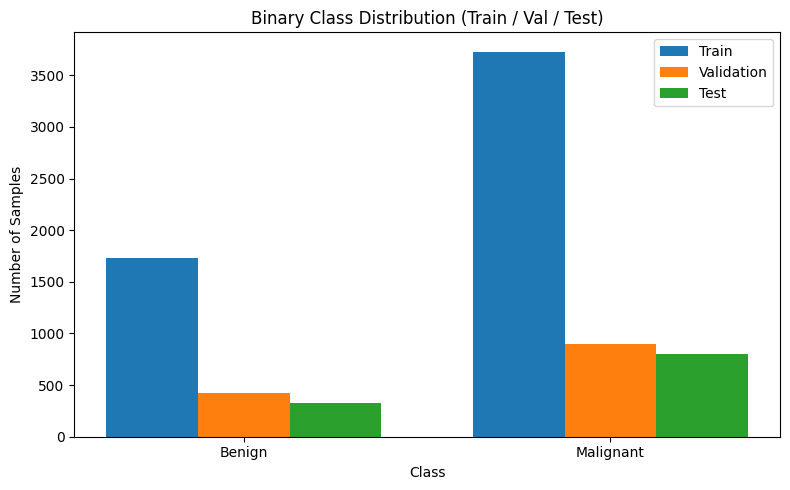

In [40]:
# =========================
# CLEAN BINARY DISTRIBUTION PLOT
# =========================

import matplotlib.pyplot as plt
from collections import Counter

# Convert to binary labels if not already
# (assuming you already mapped: 0=benign, 1=malignant)

train_count = Counter(train_labels)
val_count = Counter(val_labels)
test_count = Counter(test_labels)

classes = [0, 1]
class_names = ["Benign", "Malignant"]

train_vals = [train_count.get(c, 0) for c in classes]
val_vals = [val_count.get(c, 0) for c in classes]
test_vals = [test_count.get(c, 0) for c in classes]

x = range(len(classes))

plt.figure(figsize=(8,5))

plt.bar(x, train_vals, width=0.25, label='Train')
plt.bar([i + 0.25 for i in x], val_vals, width=0.25, label='Validation')
plt.bar([i + 0.5 for i in x], test_vals, width=0.25, label='Test')

plt.xticks([i + 0.25 for i in x], class_names)
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("Binary Class Distribution (Train / Val / Test)")
plt.legend()

plt.tight_layout()
plt.show()

# Data Transforms (Common for all models)

In [41]:

IMG_SIZE = 224
BATCH_SIZE = 32

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


# Dataset Class

In [42]:
class BreakHisDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label


full_dataset = BreakHisDataset(image_paths, labels, transform=None)

# Dataset & DataLoaders

In [43]:
# Create datasets
train_dataset = BreakHisDataset(train_paths, train_labels, transform=train_transforms)
val_dataset   = BreakHisDataset(val_paths, val_labels, transform=val_transforms)
test_dataset  = BreakHisDataset(test_paths, test_labels, transform=val_transforms)

# dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

# Sample Images Visualization

**Raw Image**

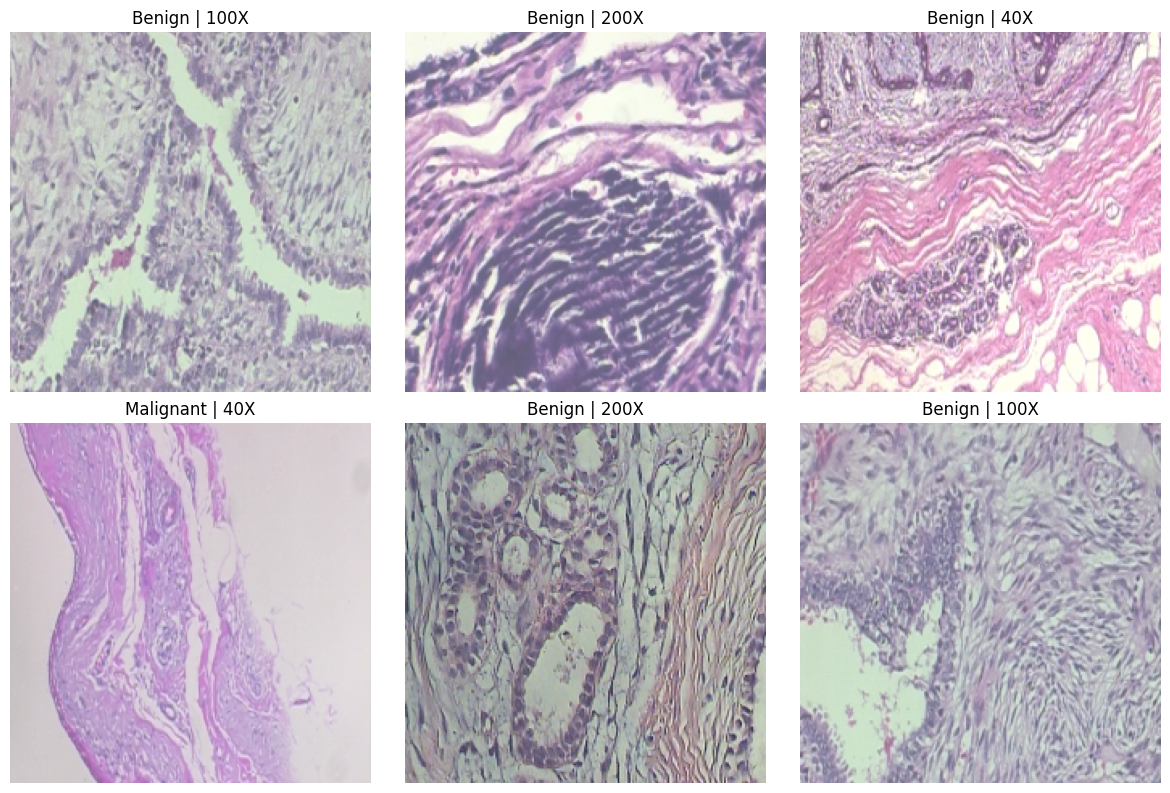

In [44]:


import matplotlib.pyplot as plt
import random
from PIL import Image

# Recreate labels from paths (same logic you used)
benign_classes = [
    "adenosis",
    "fibroadenoma",
    "phyllodes_tumor",
    "tubular_adenoma"
]

# Build a fresh correct label list
correct_labels = []

for path in image_paths:
    cls = path.split("/")[-2]   # class folder name

    if cls in benign_classes:
        correct_labels.append(0)
    else:
        correct_labels.append(1)

# Label map
label_map = {
    0: "Benign",
    1: "Malignant"
}

# Sample images
num_images = 6
indices = random.sample(range(len(image_paths)), num_images)

plt.figure(figsize=(12, 8))

for i, idx in enumerate(indices):
    img_path = image_paths[idx]
    lbl = correct_labels[idx]

    img = Image.open(img_path).convert("RGB")

    plt.subplot(2, 3, i+1)
    plt.imshow(img)

    mag = img_path.split("/")[-3]
    plt.title(f"{label_map[lbl]} | {mag}")

    plt.axis("off")

plt.tight_layout()
plt.show()

**# Transformed Image**

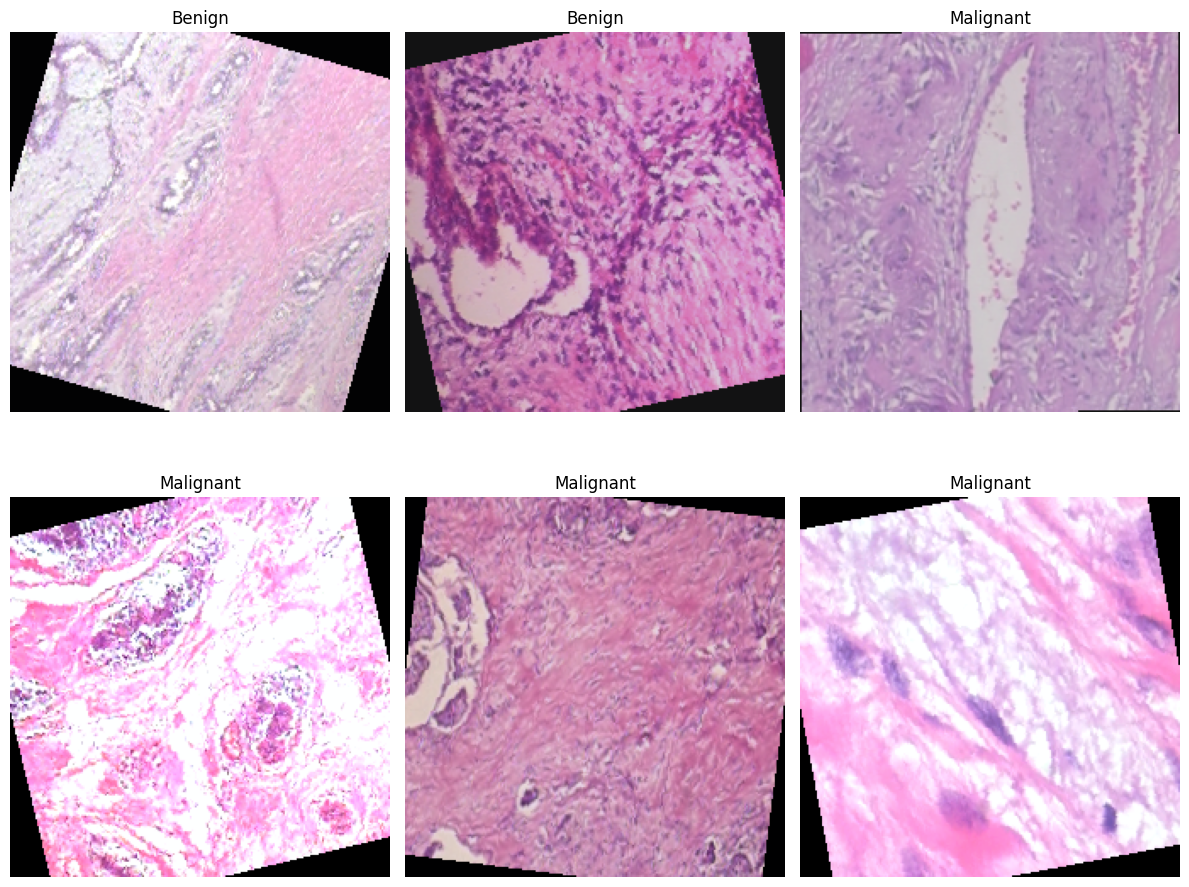

In [45]:

# Label mapping for binary classification
label_map = {
    0: "Benign",
    1: "Malignant"
}

# Function to unnormalize image
def imshow(img):
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img

# Get one batch
images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 10))

for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(imshow(images[i].cpu()))
    plt.title(label_map[labels[i].item()])
    plt.axis("off")

plt.tight_layout()
plt.show()

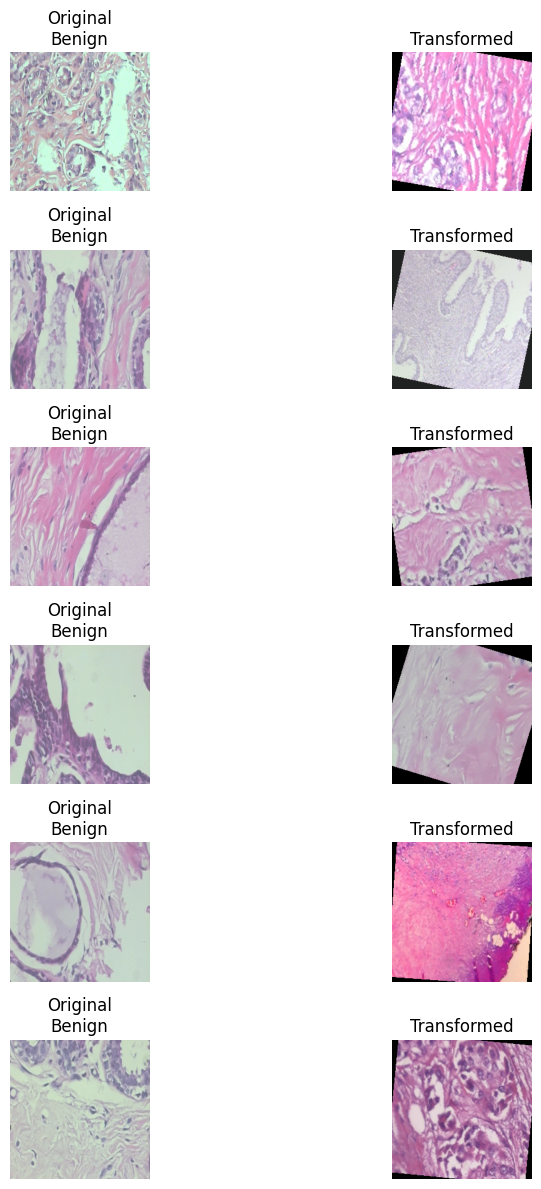

In [46]:


import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Label mapping
label_map = {
    0: "Benign",
    1: "Malignant"
}

# Unnormalize function (same as yours)
def imshow(img):
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img

# Get ONE batch (transformed images)
images, batch_labels = next(iter(train_loader))

# IMPORTANT: access underlying dataset
dataset = train_loader.dataset

plt.figure(figsize=(10, 12))

for i in range(6):
    
    # Get original image path + label from dataset
    img_path = dataset.image_paths[i]
    label = dataset.labels[i]
    
    # Load ORIGINAL image
    orig_img = Image.open(img_path).convert("RGB")
    
    # Plot ORIGINAL
    plt.subplot(6, 2, 2*i + 1)
    plt.imshow(orig_img)
    plt.title(f"Original\n{label_map[label]}")
    plt.axis("off")
    
    # Plot TRANSFORMED (from loader)
    plt.subplot(6, 2, 2*i + 2)
    plt.imshow(imshow(images[i].cpu()))
    plt.title("Transformed")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Class Weights (Handling Class Imbalance)

In [47]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from collections import Counter

# Count class distribution
train_counts = Counter(train_labels)
print("Train distribution:", train_counts)

total_samples = len(train_labels)

# Compute weights (inverse frequency)
class_weights = torch.tensor([
    total_samples / train_counts[0],  # Benign
    total_samples / train_counts[1]   # Malignant
], dtype=torch.float32).to(device)

print("Class weights:", class_weights)

# Loss function
criterion = FocalLoss(alpha=alpha, gamma=2.5)

Train distribution: Counter({1: 3730, 0: 1727})
Class weights: tensor([3.1598, 1.4630], device='cuda:0')


In [48]:
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')

        pt = torch.exp(-ce_loss)   # pt = probability of correct class

        if self.alpha is not None:
            at = self.alpha.gather(0, targets)
            ce_loss = at * ce_loss

        loss = ((1 - pt) ** self.gamma) * ce_loss

        return loss.mean()

In [49]:
alpha = class_weights / class_weights.sum()

# Training & Validation Engine (Common for all models)

**** Training Step (Single Epoch)****

In [50]:
def train_epoch(model, loader):
    model.train()
    
    total_loss = 0
    correct = 0
    
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()

    avg_loss = total_loss / len(loader)
    accuracy = correct / len(loader.dataset)
    
    return avg_loss, accuracy

**Validation Step (Single Epoch)**

In [51]:
def validate_epoch(model, loader):
    model.eval()
    
    total_loss = 0
    correct = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()

    avg_loss = total_loss / len(loader)
    accuracy = correct / len(loader.dataset)
    
    return avg_loss, accuracy

# Evaluation System (Common for all models)

In [52]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    matthews_corrcoef,
    balanced_accuracy_score,
    roc_curve,
    precision_recall_curve
)

**1.Prediction Collection Function**

In [53]:
def get_predictions(model, loader):
    model.eval()
    
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

**2.Metrics Computation**

In [54]:
def compute_metrics(y_true, y_pred, y_prob):
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()

    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Sensitivity (Recall)": recall_score(y_true, y_pred),
        "Specificity": TN / (TN + FP),
        "F1-score": f1_score(y_true, y_pred),
        "AUROC": roc_auc_score(y_true, y_prob),
        "AUPRC": average_precision_score(y_true, y_prob),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred)
    }

    return metrics, cm

**3. Plot Functions**

In [55]:
import seaborn as sns

def plot_confusion_matrix(cm):
    plt.figure(figsize=(5,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Benign", "Malignant"],
                yticklabels=["Benign", "Malignant"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

**4.ROC Curve**

In [56]:
def plot_roc(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

**5.Precision-Recall Curve**

In [57]:
def plot_pr_curve(y_true, y_prob):
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    auprc = average_precision_score(y_true, y_prob)

    plt.figure()
    plt.plot(recall, precision, label=f"AUPRC = {auprc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend()
    plt.show()

**Master Evaluation Function**

In [58]:
def evaluate_model(model, loader):
    y_true, y_pred, y_prob = get_predictions(model, loader)
    
    metrics, cm = compute_metrics(y_true, y_pred, y_prob)
    
    # Print metrics
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")
    
    # Plots
    plot_confusion_matrix(cm)
    plot_roc(y_true, y_prob)
    plot_pr_curve(y_true, y_prob)
    
    # Convert to DataFrame
    results_df = pd.DataFrame(list(metrics.items()), columns=["Metric", "Score"])
    
    return results_df

# Model 1: ResNet50

**Load Pretrained ResNet50**

In [59]:
def get_resnet50():
    model = models.resnet50(pretrained=True)
    
    # Modify final layer
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, 2)
    
    return model

model = get_resnet50().to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


**Freeze Backbone (Feature Extraction)**

In [60]:
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

**Loss Function & Optimizer**

In [61]:
# Count labels
train_counts = Counter(train_labels)
print(train_counts)

total_samples = len(train_labels)

# Create class weights
class_weights = torch.tensor([
    total_samples / train_counts[0],  # benign
    total_samples / train_counts[1]   # malignant
], dtype=torch.float32).to(device)

print("Class weights:", class_weights)

#  define loss
criterion = FocalLoss(alpha=alpha, gamma=2.5)

optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)

Counter({1: 3730, 0: 1727})
Class weights: tensor([3.1598, 1.4630], device='cuda:0')


**Training (Frozen Backbone)**

In [62]:
NUM_EPOCHS = 10
best_val_acc = 0.0

model_name = "resnet50"

for epoch in range(NUM_EPOCHS):
    
    # 🔹 Training
    train_loss, train_acc = train_epoch(model, train_loader)
    
    # 🔹 Validation
    val_loss, val_acc = validate_epoch(model, val_loader)

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    print("-" * 40)

    # 🔹 Save Best Model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f"{model_name}_best.pth")
        print(" Best model saved\n")

Epoch [1/10]
Train Loss: 0.0409 | Train Acc: 0.7658
Val Loss: 0.0395 | Val Acc: 0.7442
----------------------------------------
 Best model saved

Epoch [2/10]
Train Loss: 0.0380 | Train Acc: 0.7949
Val Loss: 0.0572 | Val Acc: 0.8340
----------------------------------------
 Best model saved

Epoch [3/10]
Train Loss: 0.0391 | Train Acc: 0.7988
Val Loss: 0.0576 | Val Acc: 0.6325
----------------------------------------
Epoch [4/10]
Train Loss: 0.0340 | Train Acc: 0.8241
Val Loss: 0.0409 | Val Acc: 0.7208
----------------------------------------
Epoch [5/10]
Train Loss: 0.0300 | Train Acc: 0.8393
Val Loss: 0.0350 | Val Acc: 0.8415
----------------------------------------
 Best model saved

Epoch [6/10]
Train Loss: 0.0316 | Train Acc: 0.8373
Val Loss: 0.0363 | Val Acc: 0.8196
----------------------------------------
Epoch [7/10]
Train Loss: 0.0325 | Train Acc: 0.8274
Val Loss: 0.0347 | Val Acc: 0.8136
----------------------------------------
Epoch [8/10]
Train Loss: 0.0332 | Train Acc: 0.

**Fine-Tuning (Unfreeze last layers)**

In [67]:
# Unfreeze layer4
for name, param in model.named_parameters():
    if "layer4" in name:
        param.requires_grad = True

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5
)

** Training (Fine-Tuning)**

In [69]:
NUM_EPOCHS_FINE = 15

model_name = "resnet50"

best_val_acc = 0.0   

for epoch in range(NUM_EPOCHS_FINE):
    
    # 🔹 Training
    train_loss, train_acc = train_epoch(model, train_loader)
    
    # 🔹 Validation
    val_loss, val_acc = validate_epoch(model, val_loader)

    print(f"[FT] Epoch [{epoch+1}/{NUM_EPOCHS_FINE}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    print("-" * 40)

    # 🔹 Save Best Model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f"{model_name}_best.pth")
        print(" Best model saved (Fine-Tuning)\n")

[FT] Epoch [1/15]
Train Loss: 0.0041 | Train Acc: 0.9822
Val Loss: 0.0324 | Val Acc: 0.9374
----------------------------------------
 Best model saved (Fine-Tuning)

[FT] Epoch [2/15]
Train Loss: 0.0044 | Train Acc: 0.9822
Val Loss: 0.0316 | Val Acc: 0.9238
----------------------------------------
[FT] Epoch [3/15]
Train Loss: 0.0041 | Train Acc: 0.9824
Val Loss: 0.0362 | Val Acc: 0.9328
----------------------------------------
[FT] Epoch [4/15]
Train Loss: 0.0041 | Train Acc: 0.9826
Val Loss: 0.0458 | Val Acc: 0.9215
----------------------------------------
[FT] Epoch [5/15]
Train Loss: 0.0036 | Train Acc: 0.9824
Val Loss: 0.0442 | Val Acc: 0.9177
----------------------------------------
[FT] Epoch [6/15]
Train Loss: 0.0037 | Train Acc: 0.9850
Val Loss: 0.0341 | Val Acc: 0.9306
----------------------------------------
[FT] Epoch [7/15]
Train Loss: 0.0042 | Train Acc: 0.9852
Val Loss: 0.0451 | Val Acc: 0.9200
----------------------------------------
[FT] Epoch [8/15]
Train Loss: 0.0046

**Test Evaluation**

Accuracy: 0.9530
Precision: 0.9697
Sensitivity (Recall): 0.9636
Specificity: 0.9273
F1-score: 0.9666
AUROC: 0.9899
AUPRC: 0.9960
MCC: 0.8870
Balanced Accuracy: 0.9454


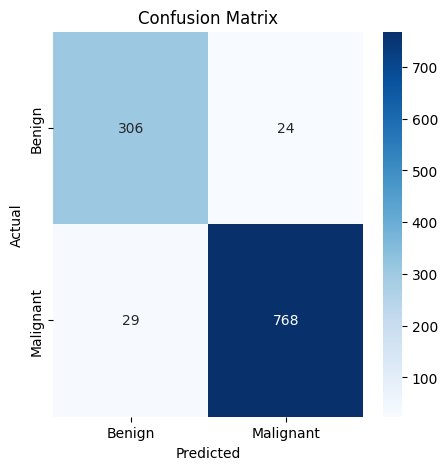

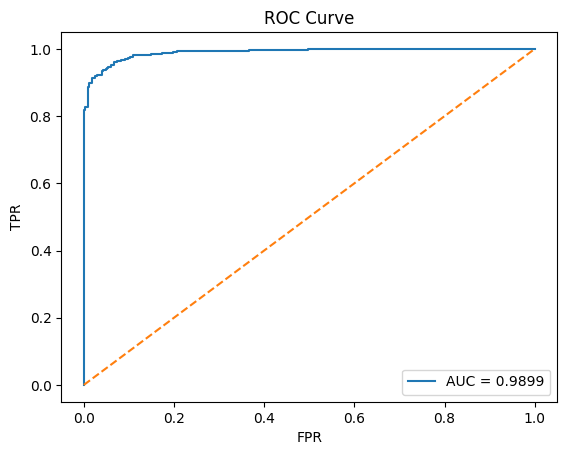

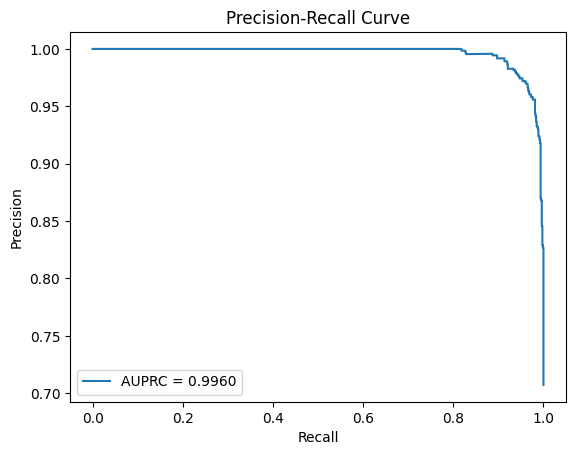

,Metric,Score
0,Accuracy,0.952972
1,Precision,0.969697
2,Sensitivity (Recall),0.963614
3,Specificity,0.927273
4,F1-score,0.966646
5,AUROC,0.989894
6,AUPRC,0.995961
7,MCC,0.887000
8,Balanced Accuracy,0.945443


In [70]:
model.load_state_dict(torch.load(f"{model_name}_best.pth"))

resnet_results = evaluate_model(model, test_loader)
resnet_results

# Model 2: DenseNet121

**Load Pretrained DenseNet121**

In [71]:
def get_densenet121():
    model = models.densenet121(pretrained=True)
    
    # Modify classifier
    in_features = model.classifier.in_features
    model.classifier = nn.Linear(in_features, 2)
    
    return model

model = get_densenet121().to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 135MB/s] 


**Freeze Backbone**

In [72]:
for param in model.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

In [73]:
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=1e-3)

**Training (Frozen Backbone)**

In [74]:
NUM_EPOCHS = 10
model_name = "densenet121"
best_val_acc = 0.0

for epoch in range(NUM_EPOCHS):
    
    train_loss, train_acc = train_epoch(model, train_loader)
    val_loss, val_acc = validate_epoch(model, val_loader)

    print(f"[DENSENET121] Epoch [{epoch+1}/{NUM_EPOCHS}]")
    print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
    print("-" * 40)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f"{model_name}_best.pth")
        print("✅ Best model saved")

[DENSENET121] Epoch [1/10]
Train Acc: 0.7383 | Val Acc: 0.8060
----------------------------------------
✅ Best model saved
[DENSENET121] Epoch [2/10]
Train Acc: 0.8343 | Val Acc: 0.8189
----------------------------------------
✅ Best model saved
[DENSENET121] Epoch [3/10]
Train Acc: 0.8400 | Val Acc: 0.7721
----------------------------------------
[DENSENET121] Epoch [4/10]
Train Acc: 0.8386 | Val Acc: 0.8506
----------------------------------------
✅ Best model saved
[DENSENET121] Epoch [5/10]
Train Acc: 0.8507 | Val Acc: 0.8287
----------------------------------------
[DENSENET121] Epoch [6/10]
Train Acc: 0.8576 | Val Acc: 0.8355
----------------------------------------
[DENSENET121] Epoch [7/10]
Train Acc: 0.8633 | Val Acc: 0.8400
----------------------------------------
[DENSENET121] Epoch [8/10]
Train Acc: 0.8633 | Val Acc: 0.8294
----------------------------------------
[DENSENET121] Epoch [9/10]
Train Acc: 0.8580 | Val Acc: 0.8498
----------------------------------------
[DENSEN

**Fine-Tuning**

In [75]:
# Unfreeze deeper layers
for name, param in model.named_parameters():
    if "denseblock4" in name:   # DenseNet equivalent of layer4
        param.requires_grad = True

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5
)

**Training (Fine-Tuning)**

In [76]:
NUM_EPOCHS_FINE = 15

for epoch in range(NUM_EPOCHS_FINE):
    
    train_loss, train_acc = train_epoch(model, train_loader)
    val_loss, val_acc = validate_epoch(model, val_loader)

    print(f"[DENSENET121 FT] Epoch [{epoch+1}/{NUM_EPOCHS_FINE}]")
    print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
    print("-" * 40)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f"{model_name}_best.pth")
        print(" Best model saved (FT)")

[DENSENET121 FT] Epoch [1/15]
Train Acc: 0.8670 | Val Acc: 0.8264
----------------------------------------
[DENSENET121 FT] Epoch [2/15]
Train Acc: 0.8900 | Val Acc: 0.8415
----------------------------------------
[DENSENET121 FT] Epoch [3/15]
Train Acc: 0.8959 | Val Acc: 0.8581
----------------------------------------
 Best model saved (FT)
[DENSENET121 FT] Epoch [4/15]
Train Acc: 0.9014 | Val Acc: 0.8581
----------------------------------------
[DENSENET121 FT] Epoch [5/15]
Train Acc: 0.9009 | Val Acc: 0.8438
----------------------------------------
[DENSENET121 FT] Epoch [6/15]
Train Acc: 0.9104 | Val Acc: 0.8634
----------------------------------------
 Best model saved (FT)
[DENSENET121 FT] Epoch [7/15]
Train Acc: 0.9115 | Val Acc: 0.8528
----------------------------------------
[DENSENET121 FT] Epoch [8/15]
Train Acc: 0.9201 | Val Acc: 0.8589
----------------------------------------
[DENSENET121 FT] Epoch [9/15]
Train Acc: 0.9159 | Val Acc: 0.8694
--------------------------------

**Test Evaluation**

Accuracy: 0.8953
Precision: 0.9582
Sensitivity (Recall): 0.8908
Specificity: 0.9061
F1-score: 0.9233
AUROC: 0.9654
AUPRC: 0.9842
MCC: 0.7642
Balanced Accuracy: 0.8985


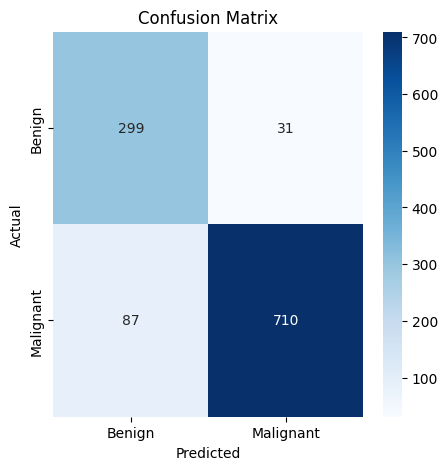

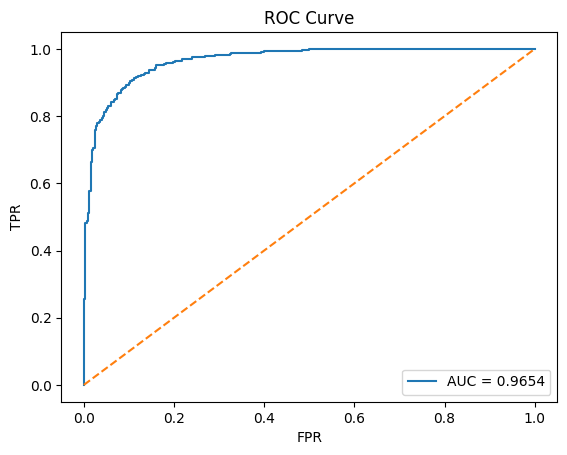

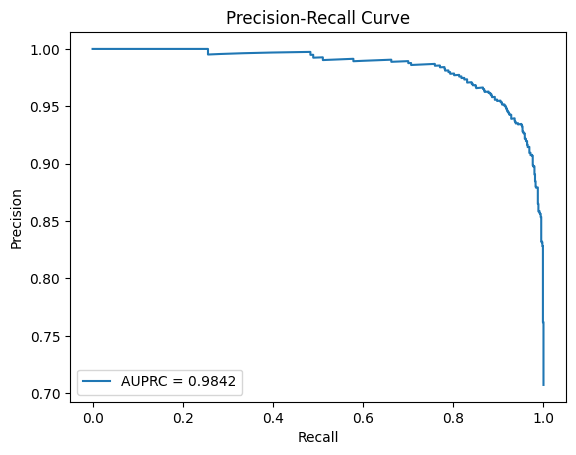

,Metric,Score
0,Accuracy,0.895297
1,Precision,0.958165
2,Sensitivity (Recall),0.890841
3,Specificity,0.906061
4,F1-score,0.923277
5,AUROC,0.965378
6,AUPRC,0.984213
7,MCC,0.764166
8,Balanced Accuracy,0.898451


In [77]:
model = get_densenet121().to(device)

model.load_state_dict(torch.load(f"{model_name}_best.pth"))

densenet_results = evaluate_model(model, test_loader)

densenet_results

# Model 3: MobileNetV2

**Model 3: MobileNetV2**

In [78]:
def get_mobilenetv2():
    model = models.mobilenet_v2(pretrained=True)
    
    # Modify classifier
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, 2)
    
    return model

model = get_mobilenetv2().to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 121MB/s]


**Freeze Backbone**

In [79]:
for param in model.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

In [80]:
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=1e-3)

**Training (Frozen Backbone)**

In [81]:
NUM_EPOCHS = 10
model_name = "mobilenetv2"
best_val_acc = 0.0

for epoch in range(NUM_EPOCHS):
    
    train_loss, train_acc = train_epoch(model, train_loader)
    val_loss, val_acc = validate_epoch(model, val_loader)

    print(f"[MOBILENETV2] Epoch [{epoch+1}/{NUM_EPOCHS}]")
    print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
    print("-" * 40)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f"{model_name}_best.pth")
        print(" Best model saved")

[MOBILENETV2] Epoch [1/10]
Train Acc: 0.7491 | Val Acc: 0.7457
----------------------------------------
 Best model saved
[MOBILENETV2] Epoch [2/10]
Train Acc: 0.7926 | Val Acc: 0.7434
----------------------------------------
[MOBILENETV2] Epoch [3/10]
Train Acc: 0.8081 | Val Acc: 0.8008
----------------------------------------
 Best model saved
[MOBILENETV2] Epoch [4/10]
Train Acc: 0.8122 | Val Acc: 0.8196
----------------------------------------
 Best model saved
[MOBILENETV2] Epoch [5/10]
Train Acc: 0.7944 | Val Acc: 0.6362
----------------------------------------
[MOBILENETV2] Epoch [6/10]
Train Acc: 0.8091 | Val Acc: 0.8445
----------------------------------------
 Best model saved
[MOBILENETV2] Epoch [7/10]
Train Acc: 0.8158 | Val Acc: 0.7630
----------------------------------------
[MOBILENETV2] Epoch [8/10]
Train Acc: 0.8158 | Val Acc: 0.7011
----------------------------------------
[MOBILENETV2] Epoch [9/10]
Train Acc: 0.8103 | Val Acc: 0.8370
---------------------------------

**Fine-Tuning**

In [82]:
# Unfreeze last layers
for name, param in model.named_parameters():
    if "features.18" in name:   # last block in MobileNetV2
        param.requires_grad = True

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5
)

**Training (Fine-Tuning)**

In [83]:
NUM_EPOCHS_FINE = 15

for epoch in range(NUM_EPOCHS_FINE):
    
    train_loss, train_acc = train_epoch(model, train_loader)
    val_loss, val_acc = validate_epoch(model, val_loader)

    print(f"[MOBILENETV2 FT] Epoch [{epoch+1}/{NUM_EPOCHS_FINE}]")
    print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
    print("-" * 40)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f"{model_name}_best.pth")
        print(" Best model saved (FT)")

[MOBILENETV2 FT] Epoch [1/15]
Train Acc: 0.8327 | Val Acc: 0.8272
----------------------------------------
[MOBILENETV2 FT] Epoch [2/15]
Train Acc: 0.8369 | Val Acc: 0.8211
----------------------------------------
[MOBILENETV2 FT] Epoch [3/15]
Train Acc: 0.8426 | Val Acc: 0.8234
----------------------------------------
[MOBILENETV2 FT] Epoch [4/15]
Train Acc: 0.8369 | Val Acc: 0.8226
----------------------------------------
[MOBILENETV2 FT] Epoch [5/15]
Train Acc: 0.8406 | Val Acc: 0.8181
----------------------------------------
[MOBILENETV2 FT] Epoch [6/15]
Train Acc: 0.8492 | Val Acc: 0.8362
----------------------------------------
[MOBILENETV2 FT] Epoch [7/15]
Train Acc: 0.8431 | Val Acc: 0.7992
----------------------------------------
[MOBILENETV2 FT] Epoch [8/15]
Train Acc: 0.8518 | Val Acc: 0.8309
----------------------------------------
[MOBILENETV2 FT] Epoch [9/15]
Train Acc: 0.8600 | Val Acc: 0.8309
----------------------------------------
[MOBILENETV2 FT] Epoch [10/15]
Train 

**Test Evaluation**

Accuracy: 0.8571
Precision: 0.9332
Sensitivity (Recall): 0.8595
Specificity: 0.8515
F1-score: 0.8948
AUROC: 0.9333
AUPRC: 0.9691
MCC: 0.6789
Balanced Accuracy: 0.8555


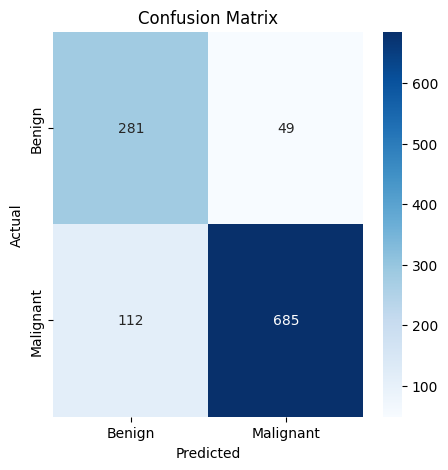

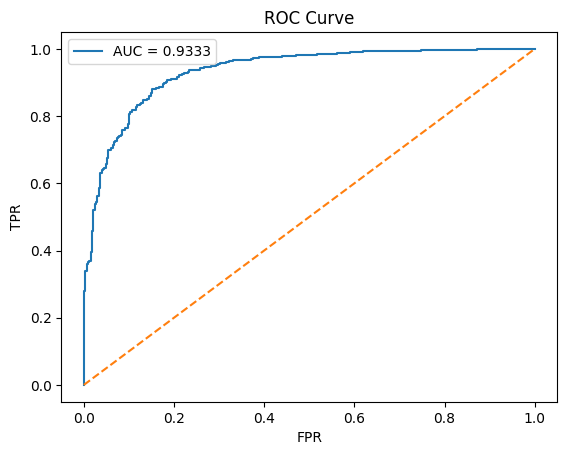

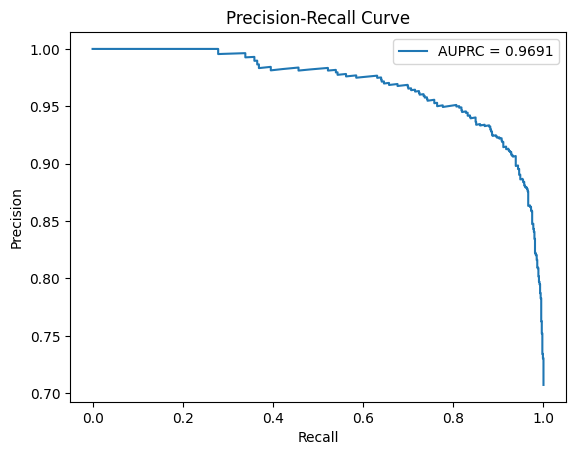

,Metric,Score
0,Accuracy,0.857143
1,Precision,0.933243
2,Sensitivity (Recall),0.859473
3,Specificity,0.851515
4,F1-score,0.894840
5,AUROC,0.933314
6,AUPRC,0.969125
7,MCC,0.678897
8,Balanced Accuracy,0.855494


In [84]:
model = get_mobilenetv2().to(device)

model.load_state_dict(torch.load(f"{model_name}_best.pth"))

mobilenet_results = evaluate_model(model, test_loader)

mobilenet_results

# Model 4: EfficientNet-B0

**Load Pretrained EfficientNet-B0**

In [85]:
def get_efficientnet_b0():
    model = models.efficientnet_b0(pretrained=True)
    
    # Modify classifier
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, 2)
    
    return model

model = get_efficientnet_b0().to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 146MB/s]


In [86]:
for param in model.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

In [87]:
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=1e-3)

In [88]:
NUM_EPOCHS = 10
model_name = "efficientnet_b0"
best_val_acc = 0.0

for epoch in range(NUM_EPOCHS):
    
    train_loss, train_acc = train_epoch(model, train_loader)
    val_loss, val_acc = validate_epoch(model, val_loader)

    print(f"[EFFICIENTNET] Epoch [{epoch+1}/{NUM_EPOCHS}]")
    print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
    print("-" * 40)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f"{model_name}_best.pth")
        print(" Best model saved")

[EFFICIENTNET] Epoch [1/10]
Train Acc: 0.7561 | Val Acc: 0.7449
----------------------------------------
 Best model saved
[EFFICIENTNET] Epoch [2/10]
Train Acc: 0.8008 | Val Acc: 0.7570
----------------------------------------
 Best model saved
[EFFICIENTNET] Epoch [3/10]
Train Acc: 0.8030 | Val Acc: 0.7660
----------------------------------------
 Best model saved
[EFFICIENTNET] Epoch [4/10]
Train Acc: 0.8052 | Val Acc: 0.7721
----------------------------------------
 Best model saved
[EFFICIENTNET] Epoch [5/10]
Train Acc: 0.8028 | Val Acc: 0.8128
----------------------------------------
 Best model saved
[EFFICIENTNET] Epoch [6/10]
Train Acc: 0.8041 | Val Acc: 0.7532
----------------------------------------
[EFFICIENTNET] Epoch [7/10]
Train Acc: 0.8138 | Val Acc: 0.8106
----------------------------------------
[EFFICIENTNET] Epoch [8/10]
Train Acc: 0.8069 | Val Acc: 0.7426
----------------------------------------
[EFFICIENTNET] Epoch [9/10]
Train Acc: 0.8083 | Val Acc: 0.8000
------

In [89]:
# Unfreeze last block
for name, param in model.named_parameters():
    if "features.6" in name:
        param.requires_grad = True

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5
)

In [90]:
NUM_EPOCHS_FINE = 20

for epoch in range(NUM_EPOCHS_FINE):
    
    train_loss, train_acc = train_epoch(model, train_loader)
    val_loss, val_acc = validate_epoch(model, val_loader)

    print(f"[EFFICIENTNET FT] Epoch [{epoch+1}/{NUM_EPOCHS_FINE}]")
    print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
    print("-" * 40)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f"{model_name}_best.pth")
        print(" Best model saved (FT)")

[EFFICIENTNET FT] Epoch [1/20]
Train Acc: 0.8180 | Val Acc: 0.8030
----------------------------------------
[EFFICIENTNET FT] Epoch [2/20]
Train Acc: 0.8309 | Val Acc: 0.8000
----------------------------------------
[EFFICIENTNET FT] Epoch [3/20]
Train Acc: 0.8373 | Val Acc: 0.8234
----------------------------------------
 Best model saved (FT)
[EFFICIENTNET FT] Epoch [4/20]
Train Acc: 0.8404 | Val Acc: 0.8204
----------------------------------------
[EFFICIENTNET FT] Epoch [5/20]
Train Acc: 0.8442 | Val Acc: 0.8174
----------------------------------------
[EFFICIENTNET FT] Epoch [6/20]
Train Acc: 0.8616 | Val Acc: 0.8189
----------------------------------------
[EFFICIENTNET FT] Epoch [7/20]
Train Acc: 0.8598 | Val Acc: 0.8226
----------------------------------------
[EFFICIENTNET FT] Epoch [8/20]
Train Acc: 0.8638 | Val Acc: 0.8294
----------------------------------------
 Best model saved (FT)
[EFFICIENTNET FT] Epoch [9/20]
Train Acc: 0.8688 | Val Acc: 0.8438
-----------------------

Accuracy: 0.8403
Precision: 0.9478
Sensitivity (Recall): 0.8193
Specificity: 0.8909
F1-score: 0.8789
AUROC: 0.9379
AUPRC: 0.9735
MCC: 0.6630
Balanced Accuracy: 0.8551


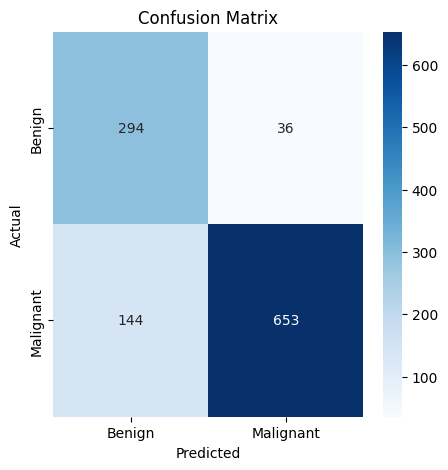

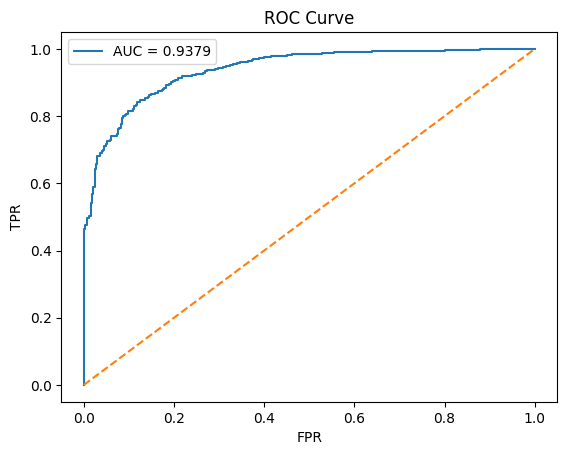

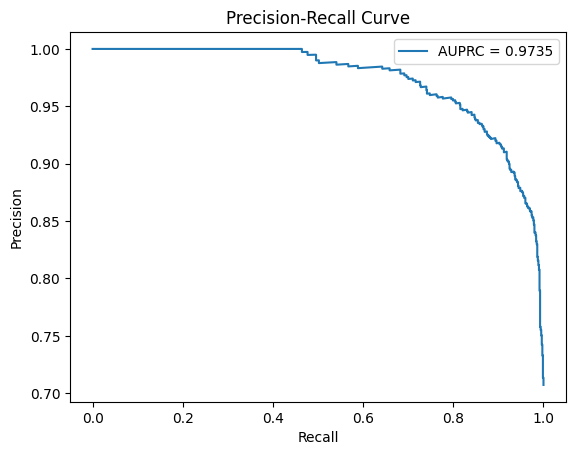

,Metric,Score
0,Accuracy,0.840284
1,Precision,0.947750
2,Sensitivity (Recall),0.819322
3,Specificity,0.890909
4,F1-score,0.878869
5,AUROC,0.937930
6,AUPRC,0.973501
7,MCC,0.663040
8,Balanced Accuracy,0.855116


In [91]:
model = get_efficientnet_b0().to(device)

model.load_state_dict(torch.load(f"{model_name}_best.pth"))

efficientnet_results = evaluate_model(model, test_loader)

efficientnet_results

#  Model Comparison (Without Transformer)

In [92]:
comparison_df = pd.DataFrame({
    "Metric": resnet_results["Metric"],
    "ResNet50": resnet_results["Score"],
    "DenseNet121": densenet_results["Score"],
    "MobileNetV2": mobilenet_results["Score"],
    "EfficientNet-B0": efficientnet_results["Score"]
})

comparison_df

,Metric,ResNet50,DenseNet121,MobileNetV2,EfficientNet-B0
0,Accuracy,0.952972,0.895297,0.857143,0.840284
1,Precision,0.969697,0.958165,0.933243,0.947750
2,Sensitivity (Recall),0.963614,0.890841,0.859473,0.819322
3,Specificity,0.927273,0.906061,0.851515,0.890909
4,F1-score,0.966646,0.923277,0.894840,0.878869
5,AUROC,0.989894,0.965378,0.933314,0.937930
6,AUPRC,0.995961,0.984213,0.969125,0.973501
7,MCC,0.887000,0.764166,0.678897,0.663040
8,Balanced Accuracy,0.945443,0.898451,0.855494,0.855116


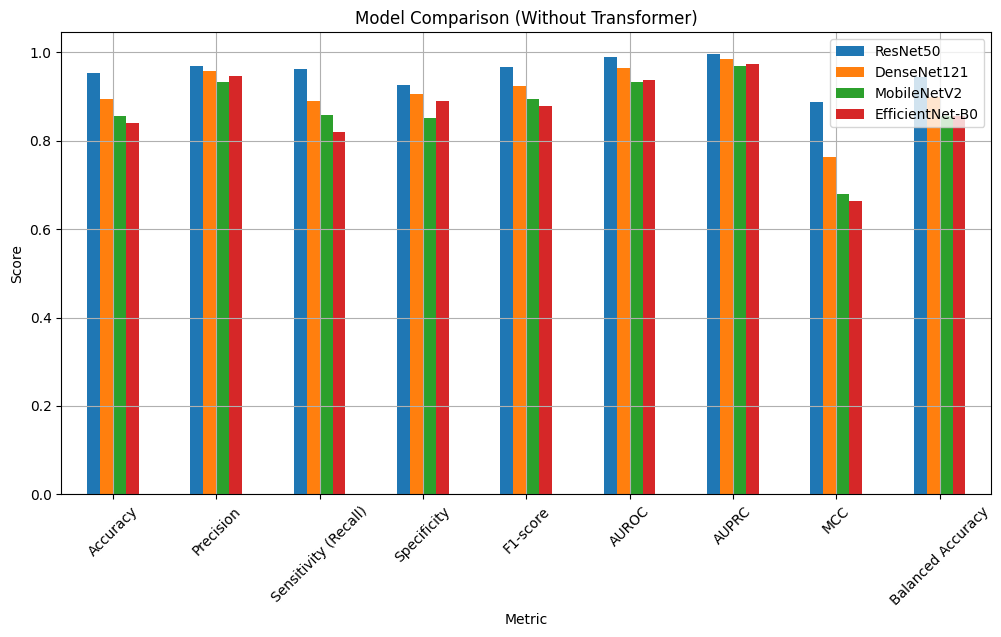

In [93]:
comparison_df.set_index("Metric").plot(kind="bar", figsize=(12,6))
plt.title("Model Comparison (Without Transformer)")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.grid()
plt.show()

#  Fusion Model (Soft Voting Ensemble)

**Load Trained Models**

In [94]:
# Define models
resnet = get_resnet50().to(device)
densenet = get_densenet121().to(device)
mobilenet = get_mobilenetv2().to(device)
efficientnet = get_efficientnet_b0().to(device)

# Load weights
resnet.load_state_dict(torch.load("resnet50_best.pth"))
densenet.load_state_dict(torch.load("densenet121_best.pth"))
mobilenet.load_state_dict(torch.load("mobilenetv2_best.pth"))
efficientnet.load_state_dict(torch.load("efficientnet_b0_best.pth"))

# Set to eval
resnet.eval()
densenet.eval()
mobilenet.eval()
efficientnet.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-dat

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

**Soft Voting Prediction**

In [95]:
def fusion_predictions(models, loader):
    
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            probs_sum = 0

            for model in models:
                outputs = model(images)
                probs = torch.softmax(outputs, dim=1)[:, 1]
                probs_sum += probs

            # Average probabilities
            avg_probs = probs_sum / len(models)

            preds = (avg_probs > 0.5).long()

            all_probs.extend(avg_probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

**Fusion Model Evaluation**

In [96]:
models_list = [resnet, densenet, mobilenet, efficientnet]

y_true, y_pred, y_prob = fusion_predictions(models_list, test_loader)

fusion_metrics, fusion_cm = compute_metrics(y_true, y_pred, y_prob)

# Print metrics
for k, v in fusion_metrics.items():
    print(f"{k}: {v:.4f}")

Accuracy: 0.9379
Precision: 0.9715
Sensitivity (Recall): 0.9398
Specificity: 0.9333
F1-score: 0.9554
AUROC: 0.9847
AUPRC: 0.9939
MCC: 0.8547
Balanced Accuracy: 0.9366


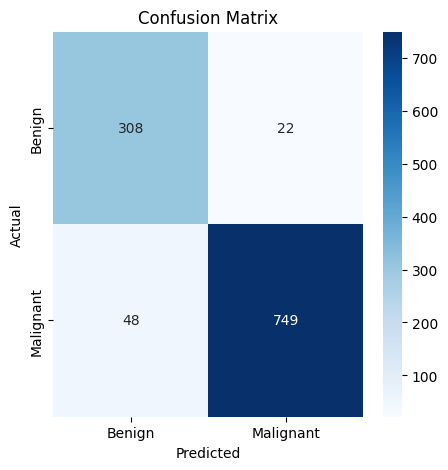

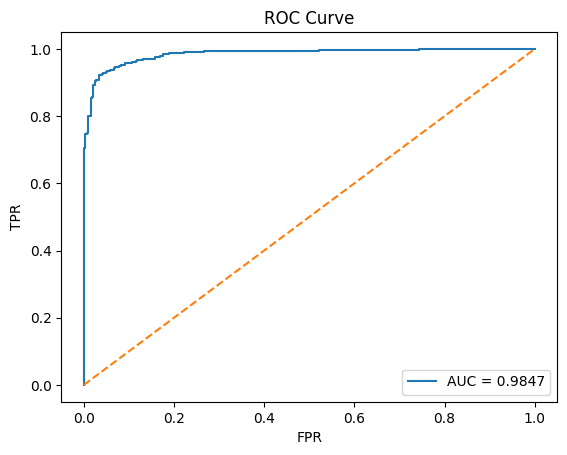

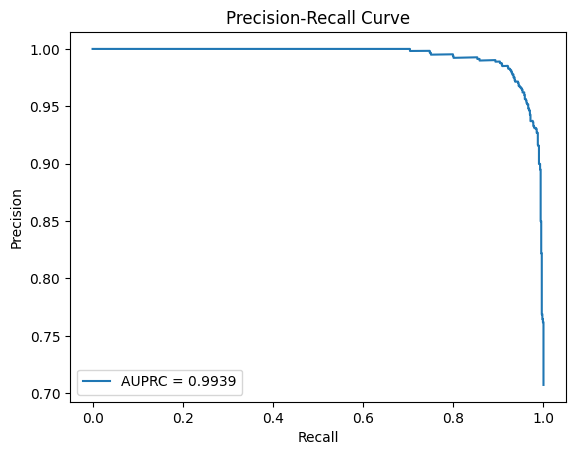

In [97]:
plot_confusion_matrix(fusion_cm)
plot_roc(y_true, y_prob)
plot_pr_curve(y_true, y_prob)

In [98]:
fusion_results = pd.DataFrame(
    list(fusion_metrics.items()),
    columns=["Metric", "Score"]
)

fusion_results

,Metric,Score
0,Accuracy,0.937888
1,Precision,0.971466
2,Sensitivity (Recall),0.939774
3,Specificity,0.933333
4,F1-score,0.955357
5,AUROC,0.984674
6,AUPRC,0.993880
7,MCC,0.854676
8,Balanced Accuracy,0.936554


In [99]:
comparison_df["Fusion Model"] = fusion_results["Score"]

comparison_df

,Metric,ResNet50,DenseNet121,MobileNetV2,EfficientNet-B0,Fusion Model
0,Accuracy,0.952972,0.895297,0.857143,0.840284,0.937888
1,Precision,0.969697,0.958165,0.933243,0.947750,0.971466
2,Sensitivity (Recall),0.963614,0.890841,0.859473,0.819322,0.939774
3,Specificity,0.927273,0.906061,0.851515,0.890909,0.933333
4,F1-score,0.966646,0.923277,0.894840,0.878869,0.955357
5,AUROC,0.989894,0.965378,0.933314,0.937930,0.984674
6,AUPRC,0.995961,0.984213,0.969125,0.973501,0.993880
7,MCC,0.887000,0.764166,0.678897,0.663040,0.854676
8,Balanced Accuracy,0.945443,0.898451,0.855494,0.855116,0.936554


#  Hybrid Model: CNN Feature Fusion + Transformer

In [100]:
class ResNetFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        
        base = get_resnet50()
        base.load_state_dict(torch.load("resnet50_best.pth"))
        
        self.features = nn.Sequential(*list(base.children())[:-1])
        
        
        for param in self.features.parameters():
            param.requires_grad = False
        
    def forward(self, x):
        with torch.no_grad():
            x = self.features(x)
        return x.view(x.size(0), -1)



class DenseNetFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        
        base = get_densenet121()
        base.load_state_dict(torch.load("densenet121_best.pth"))
        
        self.features = base.features
        self.pool = nn.AdaptiveAvgPool2d((1,1))
        
        # Freeze
        for param in self.features.parameters():
            param.requires_grad = False
        
    def forward(self, x):
        with torch.no_grad():
            x = self.features(x)
            x = self.pool(x)
        return x.view(x.size(0), -1)


class MobileNetFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        
        base = get_mobilenetv2()
        base.load_state_dict(torch.load("mobilenetv2_best.pth"))
        
        self.features = base.features
        self.pool = nn.AdaptiveAvgPool2d((1,1))
        
        # Freeze
        for param in self.features.parameters():
            param.requires_grad = False
        
    def forward(self, x):
        with torch.no_grad():
            x = self.features(x)
            x = self.pool(x)
        return x.view(x.size(0), -1)



class EfficientNetFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        
        base = get_efficientnet_b0()
        base.load_state_dict(torch.load("efficientnet_b0_best.pth"))
        
        self.features = base.features
        self.pool = nn.AdaptiveAvgPool2d((1,1))
        
        # Freeze
        for param in self.features.parameters():
            param.requires_grad = False
        
    def forward(self, x):
        with torch.no_grad():
            x = self.features(x)
            x = self.pool(x)
        return x.view(x.size(0), -1)

**FusionLayer class**

In [101]:
class FeatureFusion(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.resnet = ResNetFeatureExtractor()
        self.densenet = DenseNetFeatureExtractor()
        self.mobilenet = MobileNetFeatureExtractor()
        self.efficientnet = EfficientNetFeatureExtractor()
        
    def forward(self, x):
        f1 = self.resnet(x)
        f2 = self.densenet(x)
        f3 = self.mobilenet(x)
        f4 = self.efficientnet(x)
        
        fused = torch.cat([f1, f2, f3, f4], dim=1)
        return fused

In [102]:
class TransformerClassifier(nn.Module):
    def __init__(self, input_dim, num_classes=2):
        super().__init__()
        
        self.fc_in = nn.Linear(input_dim, 512)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=512,
            nhead=8,
            batch_first=True
        )
        
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        
        self.fc_out = nn.Linear(512, num_classes)
    
    def forward(self, x):
        x = self.fc_in(x)
        x = x.unsqueeze(1)
        x = self.transformer(x)
        x = x.squeeze(1)
        return self.fc_out(x)

In [103]:
class HybridModel(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.fusion = FeatureFusion()
        
        # Total features:
        # 2048 + 1024 + 1280 + 1280 = 5632
        self.classifier = TransformerClassifier(input_dim=5632)
    
    def forward(self, x):
        features = self.fusion(x)
        return self.classifier(features)

In [104]:
model = HybridModel().to(device)

model_name = "cnn_transformer_fusion"

criterion = FocalLoss(alpha=alpha, gamma=2.5)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

best_val_acc = float('-inf')

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-dat

In [105]:
NUM_EPOCHS = 25

for epoch in range(NUM_EPOCHS):
    
    train_loss, train_acc = train_epoch(model, train_loader)
    val_loss, val_acc = validate_epoch(model, val_loader)

    print(f"[HYBRID] Epoch [{epoch+1}/{NUM_EPOCHS}]")
    print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
    print("-" * 40)


    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f"{model_name}_best.pth")
        print(" Best model saved")

[HYBRID] Epoch [1/25]
Train Acc: 0.8908 | Val Acc: 0.9147
----------------------------------------
 Best model saved
[HYBRID] Epoch [2/25]
Train Acc: 0.9498 | Val Acc: 0.8792
----------------------------------------
[HYBRID] Epoch [3/25]
Train Acc: 0.9716 | Val Acc: 0.9185
----------------------------------------
 Best model saved
[HYBRID] Epoch [4/25]
Train Acc: 0.9463 | Val Acc: 0.9200
----------------------------------------
 Best model saved
[HYBRID] Epoch [5/25]
Train Acc: 0.9732 | Val Acc: 0.9313
----------------------------------------
 Best model saved
[HYBRID] Epoch [6/25]
Train Acc: 0.9688 | Val Acc: 0.9419
----------------------------------------
 Best model saved
[HYBRID] Epoch [7/25]
Train Acc: 0.9773 | Val Acc: 0.9223
----------------------------------------
[HYBRID] Epoch [8/25]
Train Acc: 0.9738 | Val Acc: 0.9374
----------------------------------------
[HYBRID] Epoch [9/25]
Train Acc: 0.9742 | Val Acc: 0.9396
----------------------------------------
[HYBRID] Epoch [10/

# Hybrid Model Evaluation (CNN + Transformer Fusion)

Accuracy: 0.9397
Precision: 0.9740
Sensitivity (Recall): 0.9398
Specificity: 0.9394
F1-score: 0.9566
AUROC: 0.9883
AUPRC: 0.9953
MCC: 0.8593
Balanced Accuracy: 0.9396


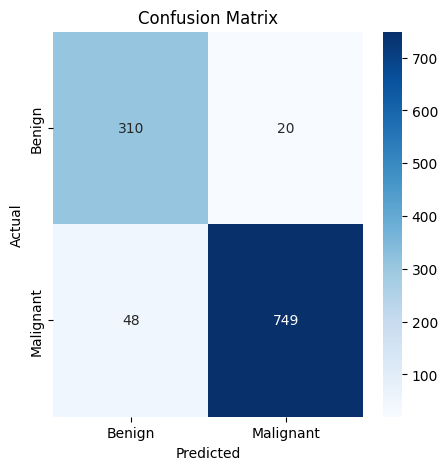

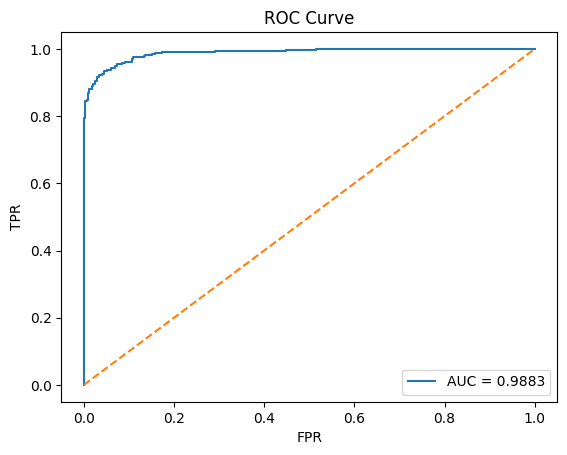

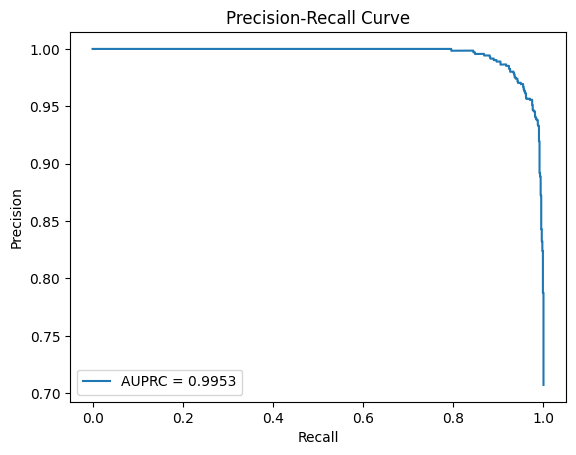

,Metric,Score
0,Accuracy,0.939663
1,Precision,0.973992
2,Sensitivity (Recall),0.939774
3,Specificity,0.939394
4,F1-score,0.956577
5,AUROC,0.988251
6,AUPRC,0.995337
7,MCC,0.859317
8,Balanced Accuracy,0.939584


In [106]:
model_name = "cnn_transformer_fusion"

model = HybridModel().to(device)

model.load_state_dict(torch.load(f"{model_name}_best.pth"))

hybrid_results = evaluate_model(model, test_loader)

hybrid_results

In [107]:
final_comparison_df = pd.DataFrame({
    "Metric": resnet_results["Metric"],
    "ResNet50": resnet_results["Score"],
    "DenseNet121": densenet_results["Score"],
    "MobileNetV2": mobilenet_results["Score"],
    "EfficientNet-B0": efficientnet_results["Score"],
    "Fusion Model": fusion_results["Score"],
    "CNN+Transformer": hybrid_results["Score"]
})

final_comparison_df

,Metric,ResNet50,DenseNet121,MobileNetV2,EfficientNet-B0,Fusion Model,CNN+Transformer
0,Accuracy,0.952972,0.895297,0.857143,0.840284,0.937888,0.939663
1,Precision,0.969697,0.958165,0.933243,0.947750,0.971466,0.973992
2,Sensitivity (Recall),0.963614,0.890841,0.859473,0.819322,0.939774,0.939774
3,Specificity,0.927273,0.906061,0.851515,0.890909,0.933333,0.939394
4,F1-score,0.966646,0.923277,0.894840,0.878869,0.955357,0.956577
5,AUROC,0.989894,0.965378,0.933314,0.937930,0.984674,0.988251
6,AUPRC,0.995961,0.984213,0.969125,0.973501,0.993880,0.995337
7,MCC,0.887000,0.764166,0.678897,0.663040,0.854676,0.859317
8,Balanced Accuracy,0.945443,0.898451,0.855494,0.855116,0.936554,0.939584


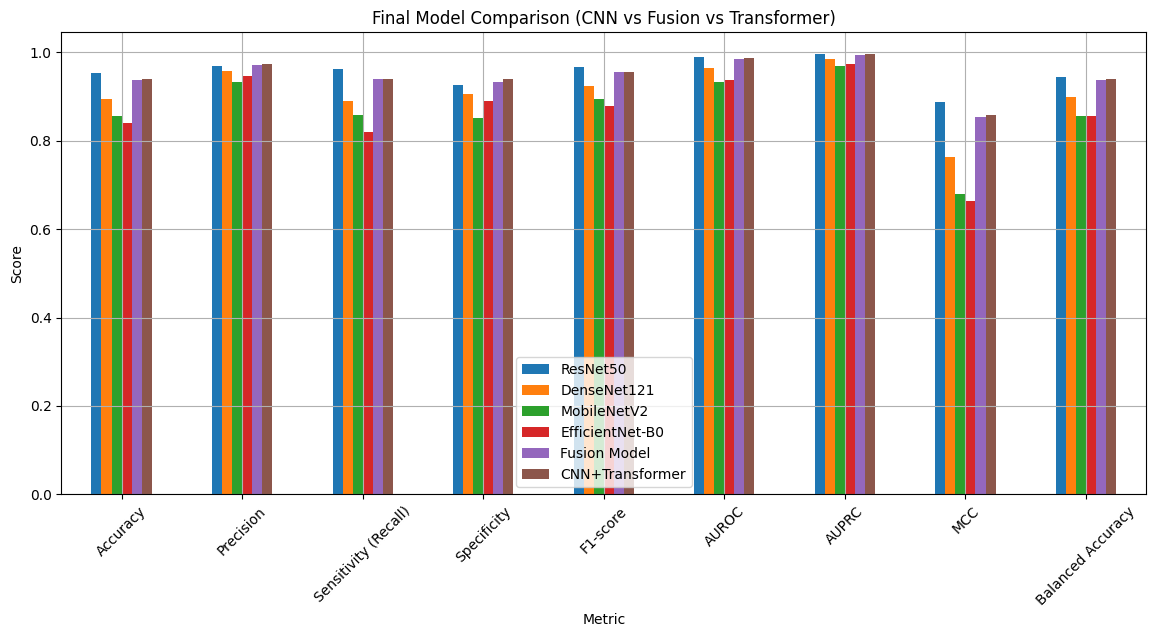

In [108]:
final_comparison_df.set_index("Metric").plot(
    kind="bar", figsize=(14,6)
)

plt.title("Final Model Comparison (CNN vs Fusion vs Transformer)")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [109]:
# 🔹 ResNet
model = get_resnet50().to(device)
model.load_state_dict(torch.load("resnet50_best.pth"))
y_true, _, resnet_probs = get_predictions(model, test_loader)

# 🔹 DenseNet
model = get_densenet121().to(device)
model.load_state_dict(torch.load("densenet121_best.pth"))
_, _, densenet_probs = get_predictions(model, test_loader)

# 🔹 MobileNet
model = get_mobilenetv2().to(device)
model.load_state_dict(torch.load("mobilenetv2_best.pth"))
_, _, mobilenet_probs = get_predictions(model, test_loader)

# 🔹 EfficientNet
model = get_efficientnet_b0().to(device)
model.load_state_dict(torch.load("efficientnet_b0_best.pth"))
_, _, efficientnet_probs = get_predictions(model, test_loader)

# 🔹 Fusion
models_list = [resnet, densenet, mobilenet, efficientnet]
y_true, _, fusion_probs = fusion_predictions(models_list, test_loader)

# 🔹 Hybrid
model = HybridModel().to(device)
model.load_state_dict(torch.load("cnn_transformer_fusion_best.pth"))
_, _, hybrid_probs = get_predictions(model, test_loader)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-dat

**Combined ROC Curve**

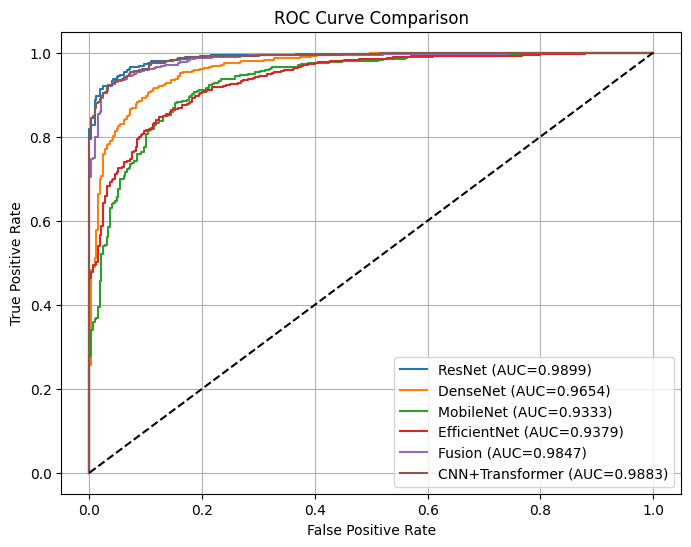

In [110]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8,6))

# ResNet
fpr, tpr, _ = roc_curve(y_true, resnet_probs)
plt.plot(fpr, tpr, label=f"ResNet (AUC={roc_auc_score(y_true, resnet_probs):.4f})")

# DenseNet
fpr, tpr, _ = roc_curve(y_true, densenet_probs)
plt.plot(fpr, tpr, label=f"DenseNet (AUC={roc_auc_score(y_true, densenet_probs):.4f})")

# MobileNet
fpr, tpr, _ = roc_curve(y_true, mobilenet_probs)
plt.plot(fpr, tpr, label=f"MobileNet (AUC={roc_auc_score(y_true, mobilenet_probs):.4f})")

# EfficientNet
fpr, tpr, _ = roc_curve(y_true, efficientnet_probs)
plt.plot(fpr, tpr, label=f"EfficientNet (AUC={roc_auc_score(y_true, efficientnet_probs):.4f})")

# Fusion
fpr, tpr, _ = roc_curve(y_true, fusion_probs)
plt.plot(fpr, tpr, label=f"Fusion (AUC={roc_auc_score(y_true, fusion_probs):.4f})")

# Hybrid
fpr, tpr, _ = roc_curve(y_true, hybrid_probs)
plt.plot(fpr, tpr, label=f"CNN+Transformer (AUC={roc_auc_score(y_true, hybrid_probs):.4f})")

# Diagonal
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()
plt.show()

**Combined Precision-Recall Curve**

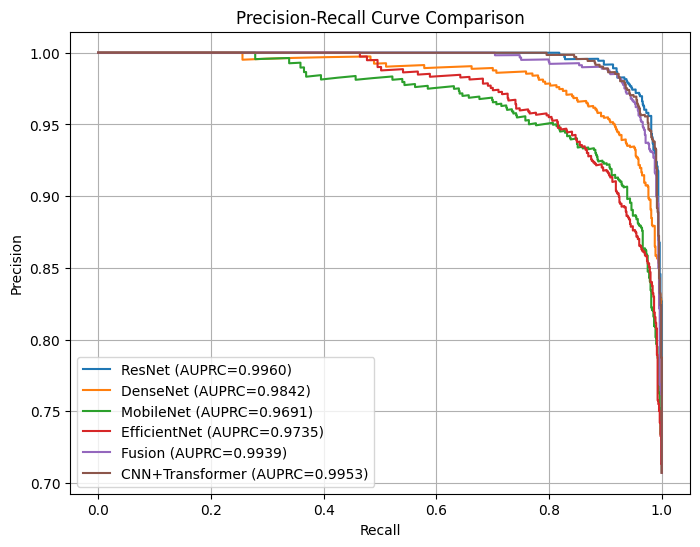

In [111]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(8,6))

# ResNet
p, r, _ = precision_recall_curve(y_true, resnet_probs)
plt.plot(r, p, label=f"ResNet (AUPRC={average_precision_score(y_true, resnet_probs):.4f})")

# DenseNet
p, r, _ = precision_recall_curve(y_true, densenet_probs)
plt.plot(r, p, label=f"DenseNet (AUPRC={average_precision_score(y_true, densenet_probs):.4f})")

# MobileNet
p, r, _ = precision_recall_curve(y_true, mobilenet_probs)
plt.plot(r, p, label=f"MobileNet (AUPRC={average_precision_score(y_true, mobilenet_probs):.4f})")

# EfficientNet
p, r, _ = precision_recall_curve(y_true, efficientnet_probs)
plt.plot(r, p, label=f"EfficientNet (AUPRC={average_precision_score(y_true, efficientnet_probs):.4f})")

# Fusion
p, r, _ = precision_recall_curve(y_true, fusion_probs)
plt.plot(r, p, label=f"Fusion (AUPRC={average_precision_score(y_true, fusion_probs):.4f})")

# Hybrid
p, r, _ = precision_recall_curve(y_true, hybrid_probs)
plt.plot(r, p, label=f"CNN+Transformer (AUPRC={average_precision_score(y_true, hybrid_probs):.4f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.grid()
plt.show()

# Classical ML Classifiers

**Feature Extraction for ML Models**

In [112]:
def extract_features(model, loader):
    model.eval()
    
    features = []
    labels = []
    
    with torch.no_grad():
        for images, y in loader:
            images = images.to(device)
            
            f = model(images)   # fused features
            
            features.append(f.cpu().numpy())
            labels.append(y.numpy())
    
    X = np.concatenate(features)
    y = np.concatenate(labels)
    
    return X, y

In [113]:
fusion_model = FeatureFusion().to(device)

X_train, y_train = extract_features(fusion_model, train_loader)
X_test, y_test = extract_features(fusion_model, test_loader)

print(X_train.shape)  # should be (N, 5632)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-dat

(5457, 5632)


# Evaluation for Classical ML Models

In [114]:
def evaluate_ml_model(y_true, y_pred, y_prob, model_name="Model"):
    
    metrics, cm = compute_metrics(y_true, y_pred, y_prob)
    
    print(f"\n=== {model_name} Results ===")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")
    
    
    plot_confusion_matrix(cm)
    plot_roc(y_true, y_prob)
    plot_pr_curve(y_true, y_prob)
    
    results_df = pd.DataFrame(
        list(metrics.items()),
        columns=["Metric", "Score"]
    )
    
    return results_df

# Random Forest

In [115]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:,1]


=== Random Forest Results ===
Accuracy: 0.9148
Precision: 0.9168
Sensitivity (Recall): 0.9674
Specificity: 0.7879
F1-score: 0.9414
AUROC: 0.9728
AUPRC: 0.9881
MCC: 0.7898
Balanced Accuracy: 0.8776


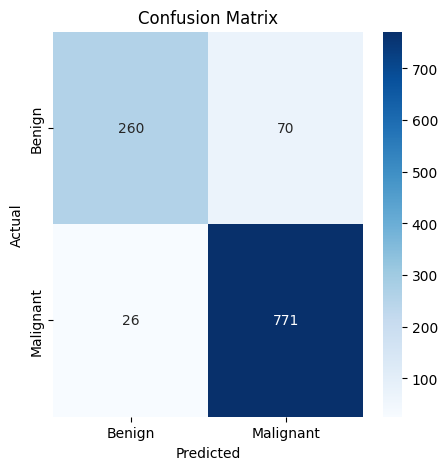

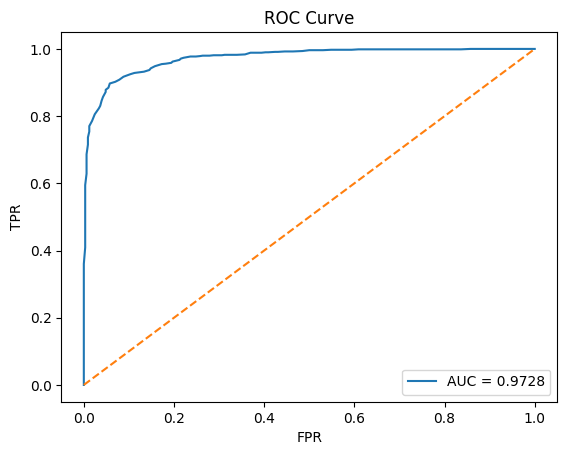

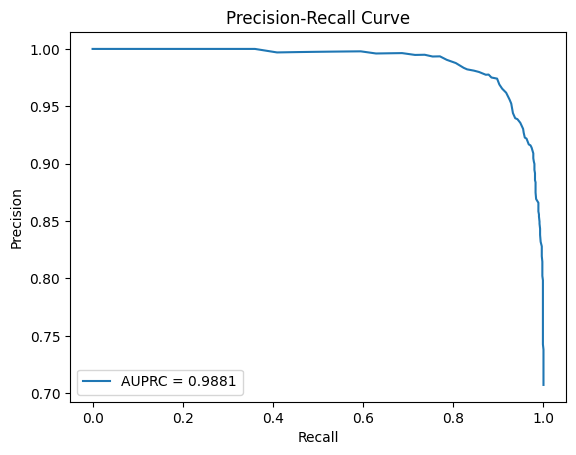

In [116]:
rf_results = evaluate_ml_model(
    y_test, rf_preds, rf_probs, model_name="Random Forest"
)

# KNeighborsClassifier

In [117]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

knn_preds = knn.predict(X_test)
knn_probs = knn.predict_proba(X_test)[:,1]


=== KNN Results ===
Accuracy: 0.8900
Precision: 0.9254
Sensitivity (Recall): 0.9184
Specificity: 0.8212
F1-score: 0.9219
AUROC: 0.9378
AUPRC: 0.9584
MCC: 0.7358
Balanced Accuracy: 0.8698


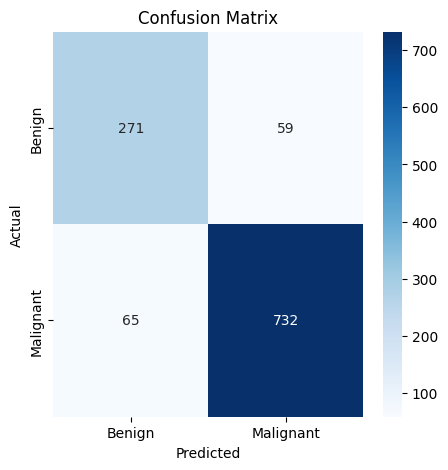

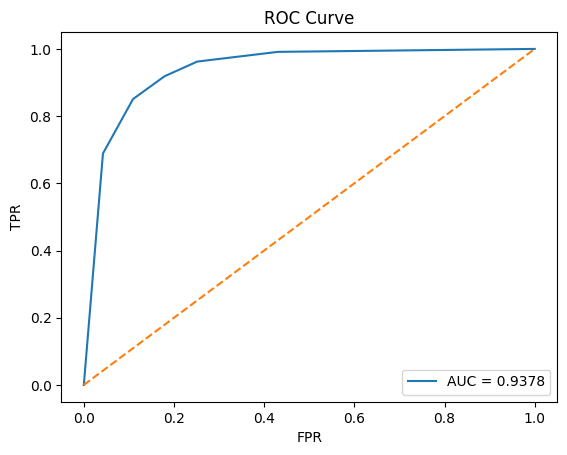

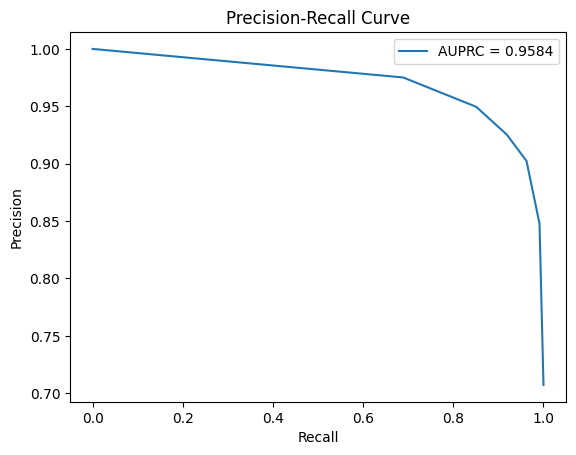

In [118]:
knn_results = evaluate_ml_model(
    y_test, knn_preds, knn_probs, model_name="KNN"
)

# SVM

In [119]:
from sklearn.svm import SVC

svm = SVC(probability=True)
svm.fit(X_train, y_train)

svm_preds = svm.predict(X_test)
svm_probs = svm.predict_proba(X_test)[:,1]


=== SVM Results ===
Accuracy: 0.9503
Precision: 0.9625
Sensitivity (Recall): 0.9674
Specificity: 0.9091
F1-score: 0.9650
AUROC: 0.9876
AUPRC: 0.9950
MCC: 0.8796
Balanced Accuracy: 0.9382


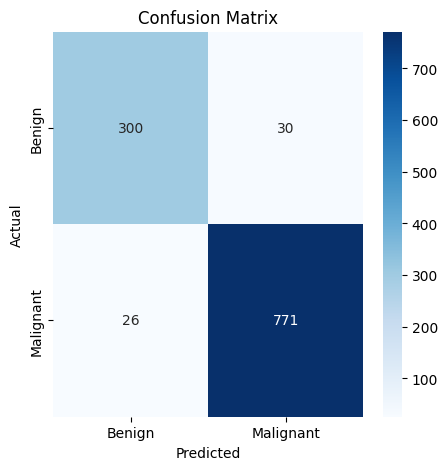

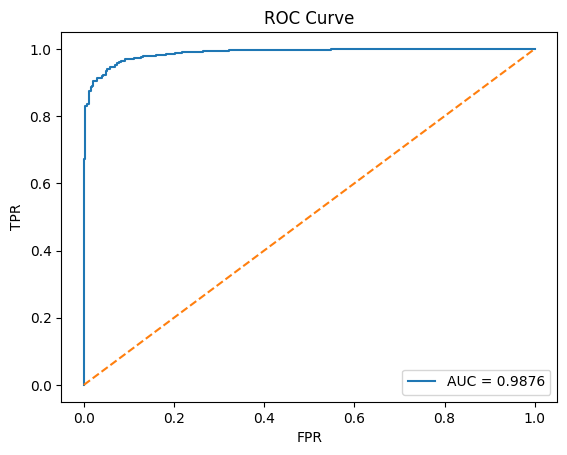

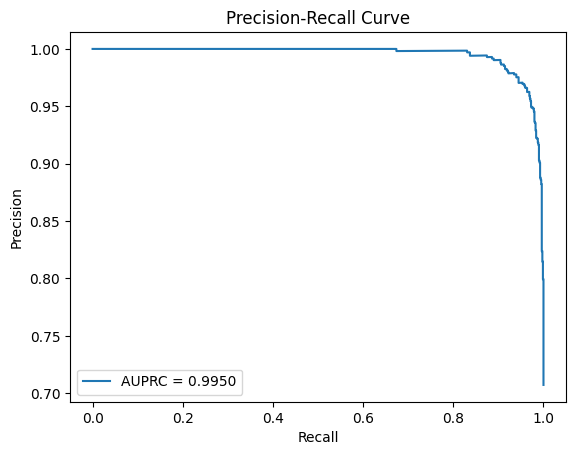

In [120]:
svm_results = evaluate_ml_model(
    y_test, svm_preds, svm_probs, model_name="SVM"
)

# LogisticRegression

In [121]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)
lr_probs = lr.predict_proba(X_test)[:,1]


=== Logistic Regression Results ===
Accuracy: 0.9494
Precision: 0.9660
Sensitivity (Recall): 0.9624
Specificity: 0.9182
F1-score: 0.9642
AUROC: 0.9882
AUPRC: 0.9952
MCC: 0.8782
Balanced Accuracy: 0.9403


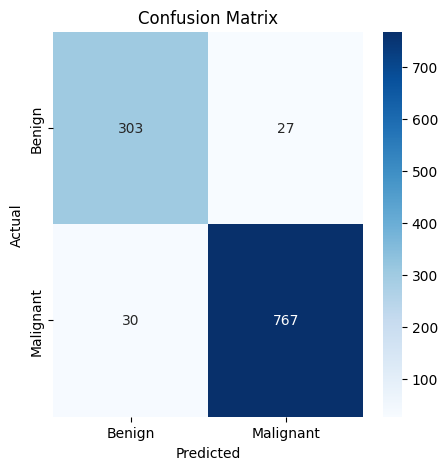

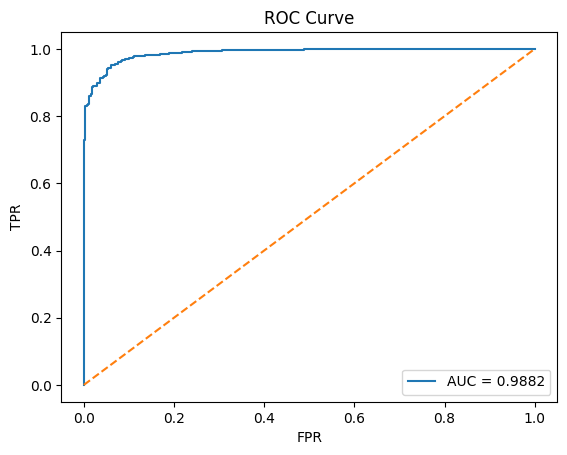

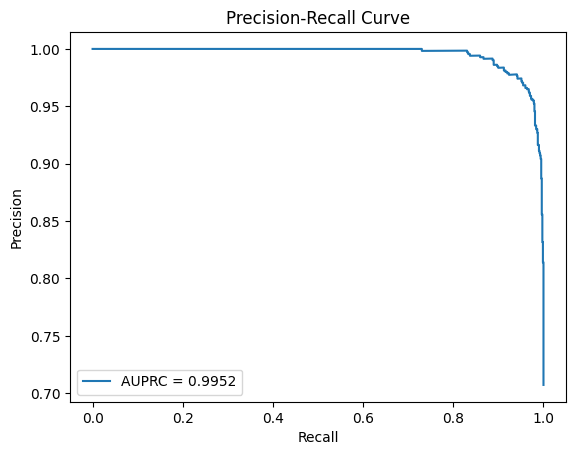

In [122]:
lr_results = evaluate_ml_model(
    y_test, lr_preds, lr_probs, model_name="Logistic Regression"
)

**Comparison Table (ML Models)**

In [131]:
print([v for v in dir() if "df" in v.lower()])

['comparison_df', 'final_comparison_df']


In [132]:
lr_df = lr_results.rename(columns={"Score": "Logistic Regression"})
knn_df = knn_results.rename(columns={"Score": "KNN"})
svm_df = svm_results.rename(columns={"Score": "SVM"})
rf_df = rf_results.rename(columns={"Score": "Random Forest"})

In [133]:
ml_comparison_df = lr_df

ml_comparison_df = pd.merge(ml_comparison_df, knn_df, on="Metric")
ml_comparison_df = pd.merge(ml_comparison_df, svm_df, on="Metric")
ml_comparison_df = pd.merge(ml_comparison_df, rf_df, on="Metric")

In [135]:
combined_df = pd.merge(
    final_comparison_df,
    ml_comparison_df.drop(columns=["CNN+Transformer"], errors="ignore"),
    on="Metric",
    how="inner"
)

In [184]:
combined_df = pd.merge(
    final_comparison_df,
    ml_comparison_df.drop(columns=["CNN+Transformer"], errors="ignore"),  # avoid duplicate column
    on="Metric",
    how="inner"
)


columns_order = [
    "Metric",
    "ResNet50",
    "DenseNet121",
    "MobileNetV2",
    "EfficientNet-B0",
    "Fusion Model",
    "CNN+Transformer",
    "Random Forest",
    "KNN",
    "SVM",
    "Logistic Regression"
]


combined_df = combined_df[[col for col in columns_order if col in combined_df.columns]]


metric_order = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC AUC",
    "PR AUC",
    "Specificity",
    "MCC",
    "Balanced Accuracy"
]

combined_df = pd.merge(
    final_comparison_df,
    ml_comparison_df,
    on="Metric",
    how="inner"   # keep only common metrics
)
combined_df = combined_df.sort_values("Metric")

# Display final table
combined_df

,Metric,ResNet50,DenseNet121,MobileNetV2,EfficientNet-B0,Fusion Model,CNN+Transformer,Logistic Regression,KNN,SVM,Random Forest
6,AUPRC,0.995961,0.984213,0.969125,0.973501,0.993880,0.995337,0.995205,0.958400,0.995010,0.988145
5,AUROC,0.989894,0.965378,0.933314,0.937930,0.984674,0.988251,0.988225,0.937807,0.987632,0.972841
0,Accuracy,0.952972,0.895297,0.857143,0.840284,0.937888,0.939663,0.949423,0.889973,0.950311,0.914818
8,Balanced Accuracy,0.945443,0.898451,0.855494,0.855116,0.936554,0.939584,0.940270,0.869828,0.938234,0.877628
4,F1-score,0.966646,0.923277,0.894840,0.878869,0.955357,0.956577,0.964173,0.921914,0.964956,0.941392
7,MCC,0.887000,0.764166,0.678897,0.663040,0.854676,0.859317,0.878220,0.735797,0.879625,0.789768
1,Precision,0.969697,0.958165,0.933243,0.947750,0.971466,0.973992,0.965995,0.925411,0.962547,0.916766
2,Sensitivity (Recall),0.963614,0.890841,0.859473,0.819322,0.939774,0.939774,0.962359,0.918444,0.967378,0.967378
3,Specificity,0.927273,0.906061,0.851515,0.890909,0.933333,0.939394,0.918182,0.821212,0.909091,0.787879


# Final Comparison (ROC - PR Curve)

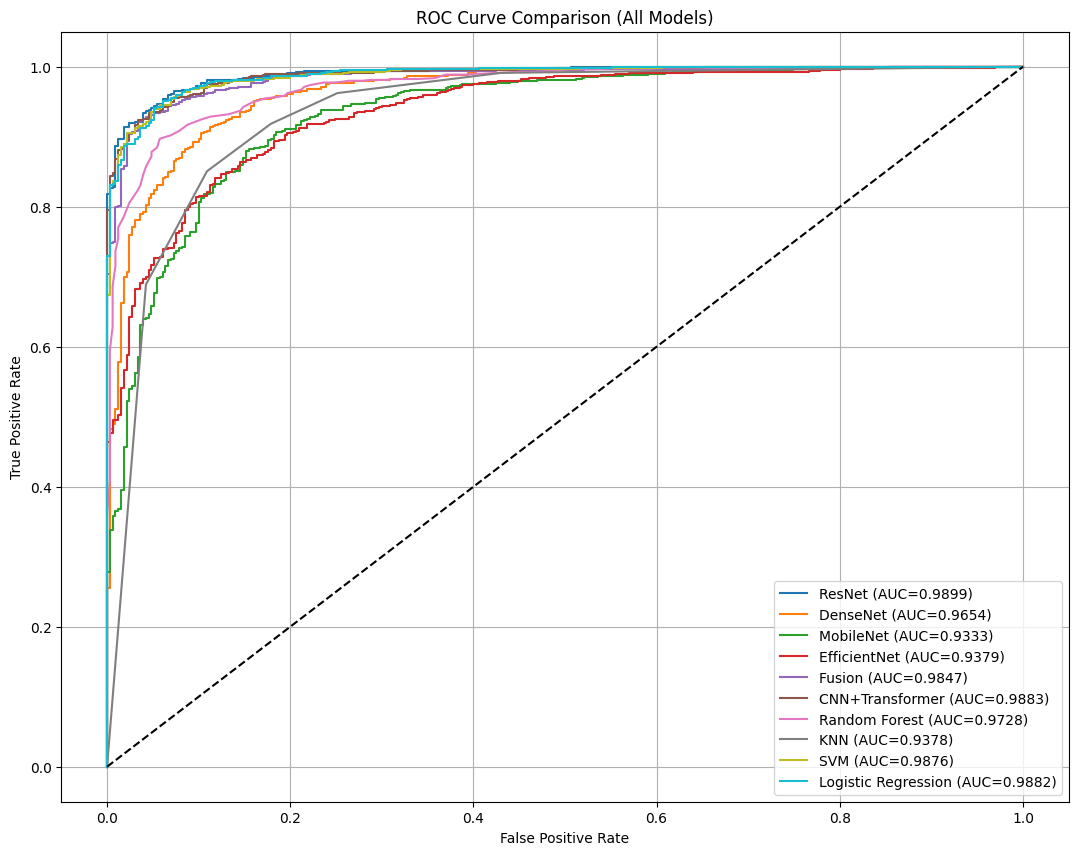

In [124]:
plt.figure(figsize=(13,10))

models_probs = {
    "ResNet": resnet_probs,
    "DenseNet": densenet_probs,
    "MobileNet": mobilenet_probs,
    "EfficientNet": efficientnet_probs,
    "Fusion": fusion_probs,
    "CNN+Transformer": hybrid_probs,
    "Random Forest": rf_probs,
    "KNN": knn_probs,
    "SVM": svm_probs,
    "Logistic Regression": lr_probs
}

for name, probs in models_probs.items():
    fpr, tpr, _ = roc_curve(y_true, probs)
    auc = roc_auc_score(y_true, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.4f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (All Models)")
plt.legend()
plt.grid()
plt.show()

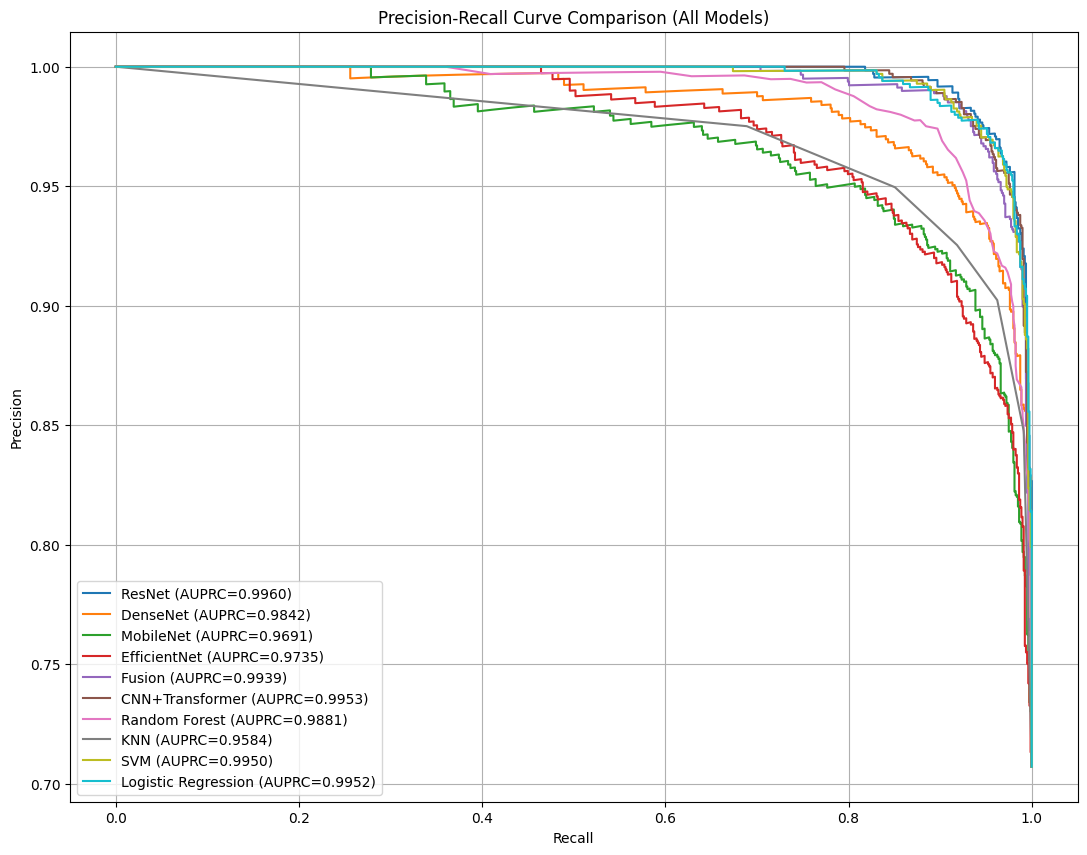

In [125]:
plt.figure(figsize=(13,10))

for name, probs in models_probs.items():
    precision, recall, _ = precision_recall_curve(y_true, probs)
    auprc = average_precision_score(y_true, probs)
    plt.plot(recall, precision, label=f"{name} (AUPRC={auprc:.4f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison (All Models)")
plt.legend()
plt.grid()
plt.show()

# Grad-CAM

In [126]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 60.6 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=3268f88d7f9ee921dd4d3b4f66edb24ce3fd566dc85ba3a936c2f3ca73c2c32d
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [127]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.gradients = None
        self.activations = None

        self.hook_layers()

    def hook_layers(self):
        def forward_hook(module, input, output):
            self.activations = output

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0]

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_backward_hook(backward_hook)

    def generate(self, input_image, class_idx=None):
        self.model.zero_grad()

        output = self.model(input_image)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        loss = output[:, class_idx]
        loss.backward()

        gradients = self.gradients
        activations = self.activations

        weights = gradients.mean(dim=(2, 3), keepdim=True)

        cam = (weights * activations).sum(dim=1)
        cam = torch.relu(cam)

        cam = cam.squeeze().cpu().detach().numpy()

        cam = (cam - cam.min()) / (cam.max() + 1e-8)

        return cam

In [128]:
resnet = get_resnet50().to(device)
resnet.load_state_dict(torch.load("resnet50_best.pth"))
resnet.eval()

densenet = get_densenet121().to(device)
densenet.load_state_dict(torch.load("densenet121_best.pth"))
densenet.eval()

mobilenet = get_mobilenetv2().to(device)
mobilenet.load_state_dict(torch.load("mobilenetv2_best.pth"))
mobilenet.eval()

efficientnet = get_efficientnet_b0().to(device)
efficientnet.load_state_dict(torch.load("efficientnet_b0_best.pth"))
efficientnet.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-dat

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [137]:
gradcam_resnet = GradCAM(resnet, resnet.layer4[-1])
gradcam_densenet = GradCAM(densenet, densenet.features[-1])
gradcam_mobilenet = GradCAM(mobilenet, mobilenet.features[-1])
gradcam_effnet = GradCAM(efficientnet, efficientnet.features[-1])


In [138]:
def denormalize(img_tensor):
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]

    img = img_tensor.clone().cpu().numpy()

    for i in range(3):
        img[i] = img[i] * std[i] + mean[i]

    img = np.transpose(img, (1,2,0))
    img = np.clip(img, 0, 1)

    return img

In [139]:
images, labels = next(iter(test_loader))

img = images[0].unsqueeze(0).to(device)
img_np = denormalize(images[0])

In [140]:
cams = {}

cams["ResNet"] = gradcam_resnet.generate(img, class_idx=1)
cams["DenseNet"] = gradcam_densenet.generate(img, class_idx=1)
cams["MobileNet"] = gradcam_mobilenet.generate(img, class_idx=1)
cams["EfficientNet"] = gradcam_effnet.generate(img, class_idx=1)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


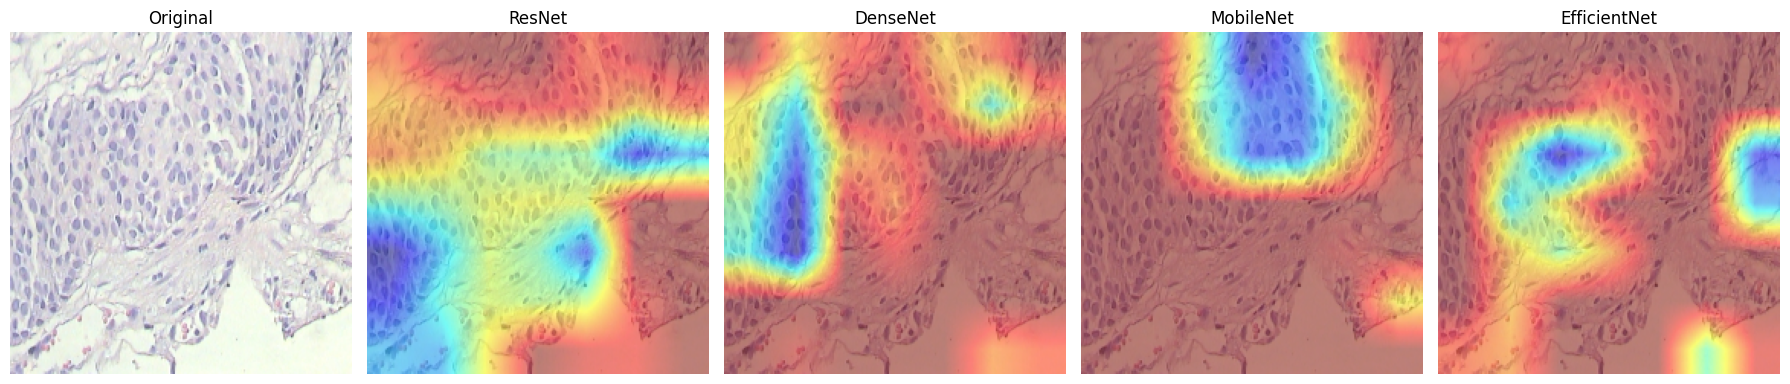

In [141]:
import cv2
import matplotlib.pyplot as plt

plt.figure(figsize=(18,5))

# Original
plt.subplot(1,5,1)
plt.title("Original")
plt.imshow(img_np)
plt.axis("off")

# Plot each model
i = 2
for name, cam in cams.items():
    cam_resized = cv2.resize(cam, (img_np.shape[1], img_np.shape[0]))

    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255

    overlay = heatmap + np.float32(img_np)
    overlay = overlay / overlay.max()

    plt.subplot(1,5,i)
    plt.title(name)
    plt.imshow(overlay)
    plt.axis("off")

    i += 1

plt.tight_layout()
plt.show()

In [142]:
!pip install lime

# LIME

In [143]:
from lime import lime_image
from skimage.segmentation import mark_boundaries


In [144]:
def denormalize(img_tensor):
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]

    img = img_tensor.clone().cpu().numpy()

    for i in range(3):
        img[i] = img[i] * std[i] + mean[i]

    img = np.transpose(img, (1,2,0))
    img = np.clip(img, 0, 1)

    return img

In [145]:
def predict_fn(images_np):
    model.eval()

    images = []
    for img in images_np:
        img = torch.tensor(img.transpose(2,0,1)).float()

        # normalize again (reverse of denormalize)
        mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
        std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)

        img = (img - mean) / std
        images.append(img)

    batch = torch.stack(images).to(device)

    with torch.no_grad():
        outputs = model(batch)
        probs = torch.softmax(outputs, dim=1)

    return probs.cpu().numpy()

In [146]:
images, labels = next(iter(test_loader))

img_tensor = images[0]
img_np = denormalize(img_tensor)

In [147]:
explainer = lime_image.LimeImageExplainer()

explanation = explainer.explain_instance(
    img_np,
    predict_fn,
    top_labels=2,
    hide_color=0,
    num_samples=1000
)

  0%|          | 0/1000 [00:00<?, ?it/s]

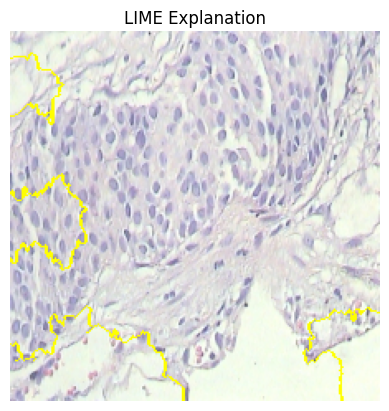

In [148]:
temp, mask = explanation.get_image_and_mask(
    label=1,   # malignant class
    positive_only=True,
    num_features=5,
    hide_rest=False
)

plt.imshow(mark_boundaries(temp, mask))
plt.title("LIME Explanation")
plt.axis("off")
plt.show()

# SHAP

In [149]:
!pip install shap

/tmp/ipykernel_55/3916475714.py:12: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test[:10])


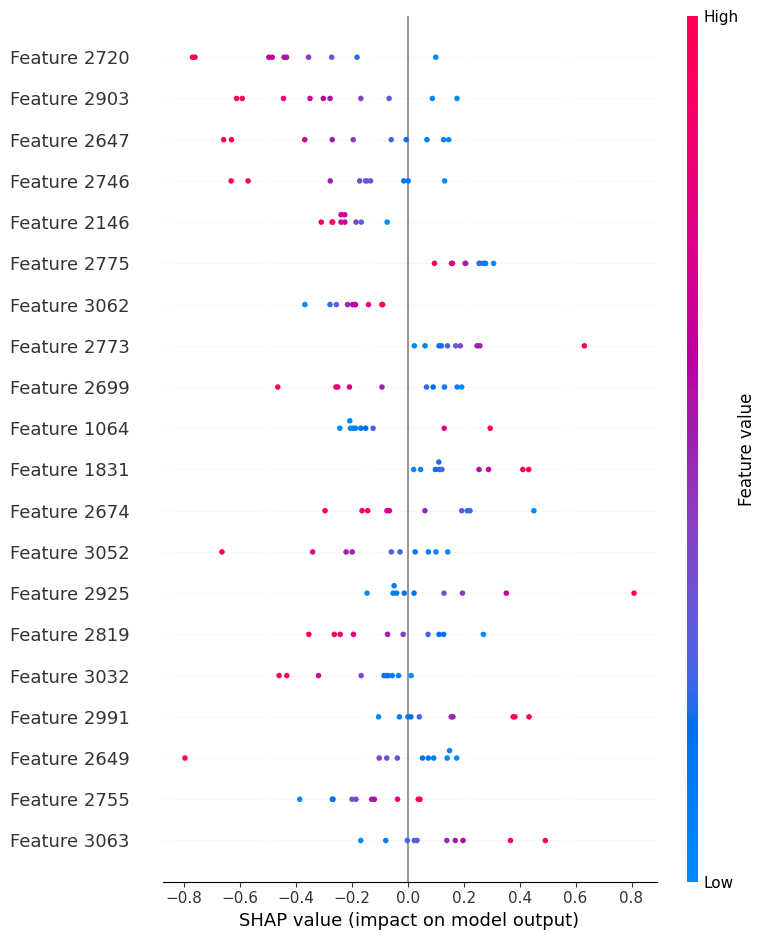

In [182]:
import shap
from sklearn.linear_model import LogisticRegression

# train model (if not already done)
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# SHAP
explainer = shap.Explainer(lr_model, X_train[:100])
shap_values = explainer(X_test[:10])

shap.summary_plot(shap_values, X_test[:10])